# 配置环境，导入数据

In [352]:
source("/home/user/data2/lit/bin/lit_utils.R")
source("/home/user/data3/lit/project/sORFs/sORFs.utils.R")
lib_text()
lib_plot()
library(readr)


Attaching package: ‘readr’


The following object is masked _by_ ‘.GlobalEnv’:

    read_file




In [226]:
# 读入ISD计算结果
fread_c("../../processed/ISD/ISD.merged.txt") -> ISD
head(ISD)
nrow(ISD)
ISD %>% distinct(`Gene ID`,.keep_all = TRUE) -> ISD
nrow(ISD)

,Gene ID,Avg ISD,Protein Length
,<chr>,<chr>,<chr>
1,PB.30926.8:chr3:+|9|403:152:365|canonical|ATG,0.3283,106
2,PB.10103.45:chr12:-|8|1180:189:312|canonical|ATG,0.2596,50
3,PB.33715.13:chr4:+|9|1774:163:421|canonical|ATG,0.1449,122
4,PB.41685.227:chr6:-|23|3485:346:682|canonical|ATG,0.3577,156
5,PB.29979.15:chr3:+|32|5423:534:732|canonical|ATG,0.3163,75
6,PB.1187.14:chr1:-|19|3337:278:491|canonical|ATG,0.9544,102


[1] 13566

[1] 13324

## 不同组别的数量

In [120]:
fread_c("../../processed/seve_list_compare/all_orfs_with_type.txt") -> all_orfs_with_type
# 只看de novo，canonical,intergenic以及lncRNA
filter(all_orfs_with_type,type%in% c("Canonical","Denovo","Intergenic","lncRNA")) -> all_orfs_with_type
nrow(all_orfs_with_type)
head(all_orfs_with_type)
table(all_orfs_with_type$type)

[1] 8561

,original_id,type,safe_id
,<chr>,<chr>,<chr>
1,146554953-146594515_193,Intergenic,146554953-146594515_193
2,190892429-191199240_2079,Intergenic,190892429-191199240_2079
3,68218080-68226652_24,Intergenic,68218080-68226652_24
4,80068757-80099536_136,Intergenic,80068757-80099536_136
5,91667782-91765898_373,Intergenic,91667782-91765898_373
6,140935010-140997951_3,Intergenic,140935010-140997951_3



 Canonical     Denovo Intergenic     lncRNA 
      2500       1141       2500       2420 

In [228]:
fread_c("../../processed/seve_list_compare/canonical_orfs.sample.2.5k.lt.150aa.txt") -> canonical_orfs
fread_c("../../processed/seve_list_compare/lnc_orfs.txt") -> lnc_orfs
fread_c("/home/user/data3/lit/project/sORFs/11-denovo-list/processed/new_list_20251128/denovo_list.txt") -> denovo_orfs
nrow(denovo_orfs)
cols <- c("ORF_id","ORF_seq","CDS_seq")
rbind(canonical_orfs[,cols],lnc_orfs[,cols],denovo_orfs[,cols]) -> all_orfs_detail

fread_c("../../processed/seve_list_compare/intergenic_orfs.sample.2.5k.lt.150aa.aa.tab") -> intergenic_id_prot_seq
fread_c("../../processed/seve_list_compare/intergenic_orfs.sample.2.5k.lt.150aa.tab") -> intergenic_id_cds_seq
merge(intergenic_id_prot_seq,intergenic_id_cds_seq,by="V1") %>% select(V1,V2.x,V2.y) -> intergenic_orf
colnames(intergenic_orf) <- c("ORF_id","ORF_seq","CDS_seq")
# head(intergenic_orf)
rbind(all_orfs_detail,intergenic_orf) -> all_orfs_detail_1
nrow(all_orfs_detail_1)
head(all_orfs_detail_1,1)%>% print()

[1] 1141

[1] 8561

                                         ORF_id
1 PB.30926.8:chr3:+|9|403:152:365|canonical|ATG
                                                                 ORF_seq
1 MFTRAQVRRILQRVPGKQRFGIYRFLPFFFVLGGTMEWIMIKVRVGQETFYDVYRRKASERQYQRRLEDE
                                                                                                                                                                                                             CDS_seq
1 ATGTTCACCAGGGCCCAGGTGAGACGGATTCTGCAGCGGGTGCCCGGGAAGCAGCGATTTGGCATCTACCGGTTCCTGCCCTTCTTTTTTGTCCTGGGAGGAACGATGGAGTGGATCATGATTAAAGTGCGCGTGGGCCAGGAGACCTTCTATGATGTCTACCGTAGAAAAGCCTCAGAAAGACAGTATCAGAGAAGGCTGGAAGATGAA


In [229]:
all_orfs_detail_1 %>% distinct(ORF_id,.keep_all = TRUE) -> all_orfs_detail_1
nrow(all_orfs_detail_1)

[1] 8556

In [230]:
merge(all_orfs_with_type,all_orfs_detail_1,by.x="original_id",by.y="ORF_id") ->all_orfs_detail_2

In [231]:
all_orfs_detail_2$ORF_length <- str_count(all_orfs_detail_2$ORF_seq)
head(all_orfs_detail_2,1) %>% print()

   original_id       type      safe_id
1 0-253742_649 Intergenic 0-253742_649
                                       ORF_seq
1 MQTLKVAQSALYLSSIRPRTSVDSNGCLVCSLSVLNETQAQCRL
                                                                                                                               CDS_seq
1 ATGCAGACTCTAAAGGTTGCACAGTCTGCACTATATCTGTCCTCAATTAGACCTAGGACCAGTGTCGACTCTAATGGTTGCCTAGTCTGCTCTCTATCTGTCCTCAATGAGACCCAGGCACAATGCAGACTC
  ORF_length
1         44


# 绘图设置

In [232]:
# # 设置颜色（可根据需要调整）
# type_colors <- c(
#     "Canonical" = "#E64B35",
#     "De novo human/hominoid genes" = "#4DBBD5",
#     "De novo" = "#4DBBD5",
#     "lncRNA" = "#00A087"
# )

In [233]:
# 需要 rlang >= 0.4，支持 {{ }} 注入

violin_plot <- function(df, x, y, fill = x,
                        type_colors = NULL,
                        y_breaks = c(0.01, 0.1, 1, 10, 100),
                        y_label = "NC ratio") {
  ggplot(df, aes(x = {{x}}, y = {{y}}, fill = {{fill}})) +
    geom_violin(alpha = 0.6, trim = FALSE,scale = "width",width=0.6) +
    geom_boxplot(width = 0.2, alpha = 0.8, outlier.shape = NA) +
    { if (!is.null(type_colors)) scale_fill_manual(values = type_colors) else scale_fill_brewer(palette = "Set2") } +
    labs(x = NULL, y = y_label) +
    guides(fill = "none") +
    theme_3(rotate = T)
}
# scale_y_log10(breaks = y_breaks, labels = sprintf("%.2f", y_breaks))

In [234]:
all_orfs_detail_2 -> all
table(all$type)


 Canonical     Denovo Intergenic     lncRNA 
      2500       1141       2500       2420 

In [235]:
LEVELS <- c("Intergenic","lncRNA","Denovo","Canonical")
all$type <- factor(all$type,levels=LEVELS)
type_names <- as.character(unique(all$type))
type_pairs <- combn(type_names, 2, simplify = FALSE)
type_pairs

[[1]]
[1] "Intergenic" "lncRNA"    

[[2]]
[1] "Intergenic" "Canonical" 

[[3]]
[1] "Intergenic" "Denovo"    

[[4]]
[1] "lncRNA"    "Canonical"

[[5]]
[1] "lncRNA" "Denovo"

[[6]]
[1] "Canonical" "Denovo"

# 长度比较

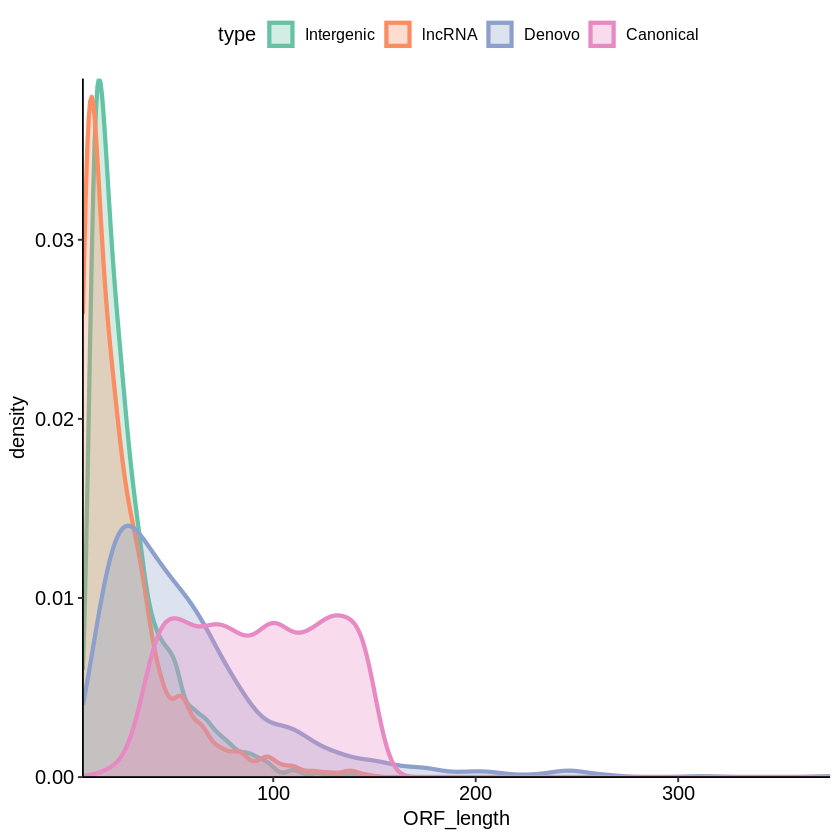

In [236]:
ggplot(all, aes(x = ORF_length, 
                             color = type, fill = type)) +
    geom_density(alpha = 0.3, size = 1.2) +
theme_3()+
scale_fill_brewer(palette = "Set2")+
scale_color_brewer(palette = "Set2")+
scale_y_continuous(expand = c(0, 0)) +
scale_x_continuous(expand = c(0, 0)) 

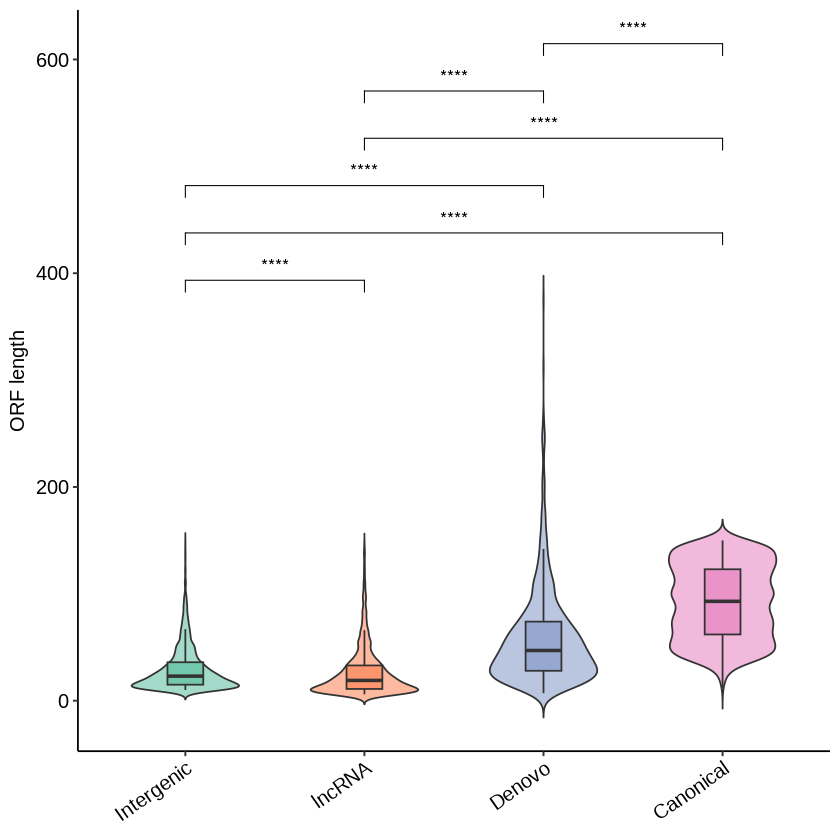

In [237]:
p <- violin_plot(all , x = type, y = ORF_length, fill = type,y_label = "ORF length")
compare(p, type_pairs) -> p_orf_length
p_orf_length

In [238]:
all %>% group_by(type) %>% summarise(min(ORF_length),max(ORF_length),median(ORF_length),mean(ORF_length))

type,min(ORF_length),max(ORF_length),median(ORF_length),mean(ORF_length)
<fct>,<int>,<int>,<dbl>,<dbl>
Intergenic,10,148,23,29.26280
lncRNA,6,147,19,26.54215
Denovo,7,375,47,58.36109
Canonical,12,150,93,92.16920


In [239]:
# 统一拉到10以上确实会改变数值
all %>% filter(ORF_length>=10) %>% group_by(type) %>% summarise(min(ORF_length),max(ORF_length),median(ORF_length),mean(ORF_length))

type,min(ORF_length),max(ORF_length),median(ORF_length),mean(ORF_length)
<fct>,<int>,<int>,<dbl>,<dbl>
Intergenic,10,148,23,29.26280
lncRNA,10,147,23,31.01990
Denovo,10,375,48,59.20945
Canonical,12,150,93,92.16920


# GC含量

In [240]:
# ===== 1. 计算GC含量 =====
calculate_gc_content <- function(seq) {
    # 转换为大写
    seq_upper <- toupper(seq)
    # 计算G和C的数量
    gc_count <- str_count(seq_upper, "[GC]")
    # 计算总碱基数（排除N）
    total_count <- str_count(seq_upper, "[ATCG]")
    # 计算GC百分比
    gc_percent <- gc_count / total_count
    return(gc_percent)
}

# 为all数据框添加GC含量列
all <- all %>%
    mutate(GC_content = sapply(CDS_seq, calculate_gc_content))

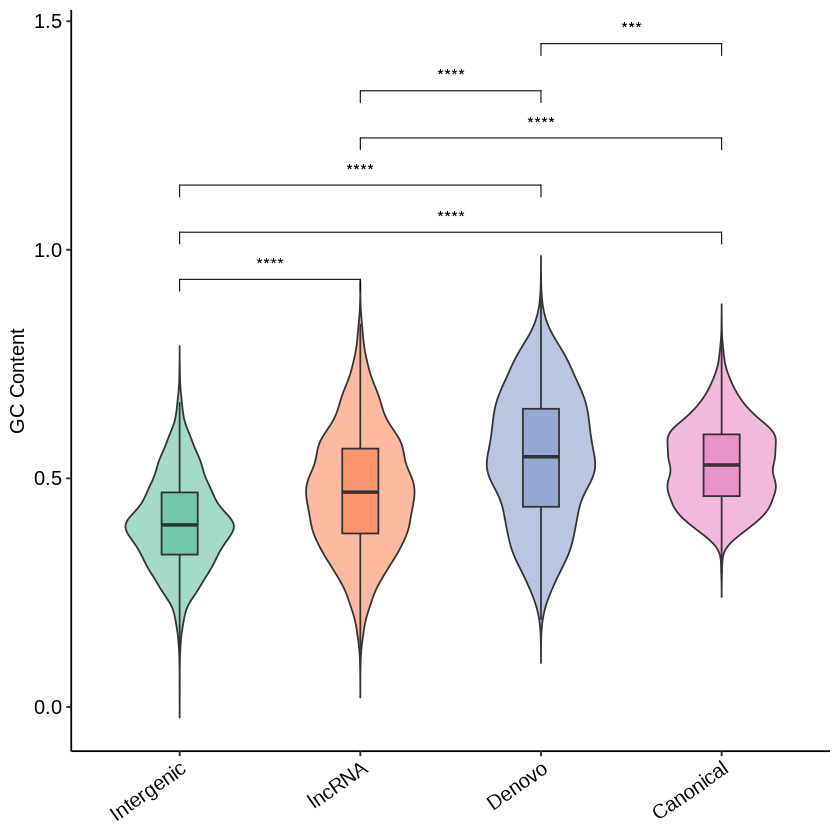

In [241]:
p1 <- violin_plot(all , x = type, y = GC_content, fill = type,y_label = "GC Content")
compare(p1, type_pairs) -> p_gc
p_gc
# ggsave(filename = out_name_1("NC_ratio"),height = 6,width = 3)

# C端疏水性

In [242]:
library(Peptides)
nrow(all)
all <- all %>%
      mutate(Last15A = substr(ORF_seq,start = ORF_length-14, stop=ORF_length)) %>% 
mutate(Hydrophobicity_full = hydrophobicity(ORF_seq, scale = "Miyazawa")) %>% 
mutate(Hydrophobicity_Last15A = hydrophobicity(Last15A, scale = "Miyazawa")) -> all
head(all[,c("Last15A","Hydrophobicity_full","Hydrophobicity_Last15A")])

[1] 8561

,Last15A,Hydrophobicity_full,Hydrophobicity_Last15A
,<chr>,<dbl>,<dbl>
1,CSLSVLNETQAQCRL,5.666818,5.745333
2,VVSTFECSDTTPLTI,6.161765,5.784667
3,SEKRDIITSFNLYMC,6.010893,5.912000
4,PRRVCIELKLVKCMT,6.610000,6.140667
5,ASRVAGTTGARHHTS,5.883226,4.852667
6,KVKIFYPKTCFFAIF,6.019333,6.518000


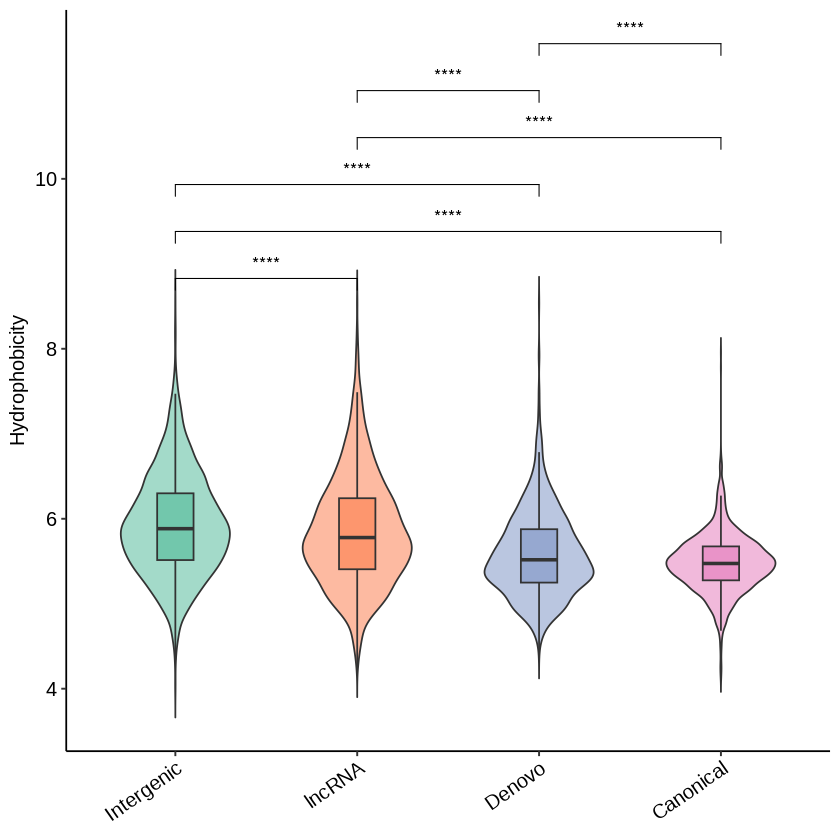

In [243]:
p1 <- violin_plot(all, x = type, y = Hydrophobicity_full, fill = type, y_label = "Hydrophobicity")
compare(p1, type_pairs) -> p_hydro
p_hydro

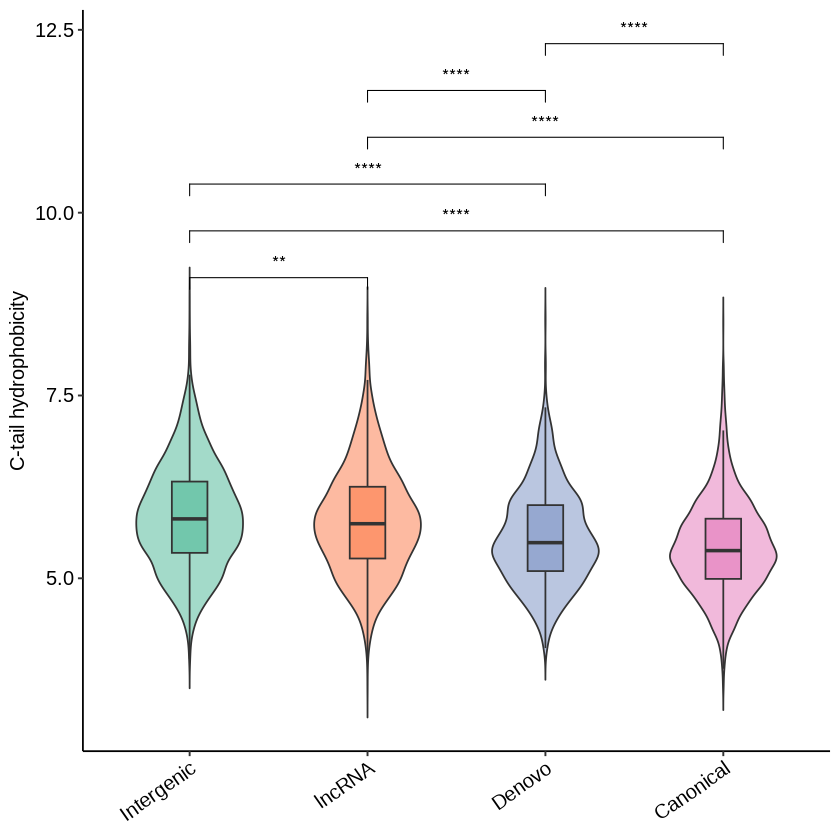

In [244]:
p1 <- violin_plot(all, x = type, y = Hydrophobicity_Last15A, fill = type, y_label = "C-tail hydrophobicity")
compare(p1, type_pairs)-> p_hydro_c_tail
p_hydro_c_tail

# ISD

In [245]:
head(all,1)
nrow(all)
head(ISD,1)
colnames(ISD) <- c("ORF_id","Avg_ISD","Protein_length")
ISD$Avg_ISD <- as.numeric(ISD$Avg_ISD)
merge(all,ISD,by.x="original_id",by.y="ORF_id") -> all_add_ISD
head(all_add_ISD,1)
colnames(all_add_ISD)
nrow(all_add_ISD)
table(all_add_ISD$type)
all_add_ISD$type <- factor(all_add_ISD$type,levels=LEVELS)

,original_id,type,safe_id,ORF_seq,CDS_seq,ORF_length,GC_content,Last15A,Hydrophobicity_full,Hydrophobicity_Last15A
,<chr>,<fct>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<dbl>,<dbl>
1,0-253742_649,Intergenic,0-253742_649,MQTLKVAQSALYLSSIRPRTSVDSNGCLVCSLSVLNETQAQCRL,ATGCAGACTCTAAAGGTTGCACAGTCTGCACTATATCTGTCCTCAATTAGACCTAGGACCAGTGTCGACTCTAATGGTTGCCTAGTCTGCTCTCTATCTGTCCTCAATGAGACCCAGGCACAATGCAGACTC,44,0.4772727,CSLSVLNETQAQCRL,5.666818,5.745333


[1] 8561

,Gene ID,Avg ISD,Protein Length
,<chr>,<chr>,<chr>
1,PB.30926.8:chr3:+|9|403:152:365|canonical|ATG,0.3283,106


Warning message in eval(expr, envir, enclos):
“NAs introduced by coercion”


,original_id,type,safe_id,ORF_seq,CDS_seq,ORF_length,GC_content,Last15A,Hydrophobicity_full,Hydrophobicity_Last15A,Avg_ISD,Protein_length
,<chr>,<fct>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,0-253742_649,Intergenic,0-253742_649,MQTLKVAQSALYLSSIRPRTSVDSNGCLVCSLSVLNETQAQCRL,ATGCAGACTCTAAAGGTTGCACAGTCTGCACTATATCTGTCCTCAATTAGACCTAGGACCAGTGTCGACTCTAATGGTTGCCTAGTCTGCTCTCTATCTGTCCTCAATGAGACCCAGGCACAATGCAGACTC,44,0.4772727,CSLSVLNETQAQCRL,5.666818,5.745333,0.273,51


[1] "original_id"            "type"                   "safe_id"               
 [4] "ORF_seq"                "CDS_seq"                "ORF_length"            
 [7] "GC_content"             "Last15A"                "Hydrophobicity_full"   
[10] "Hydrophobicity_Last15A" "Avg_ISD"                "Protein_length"

[1] 7605


Intergenic     lncRNA     Denovo  Canonical 
      2500       1783        830       2492 

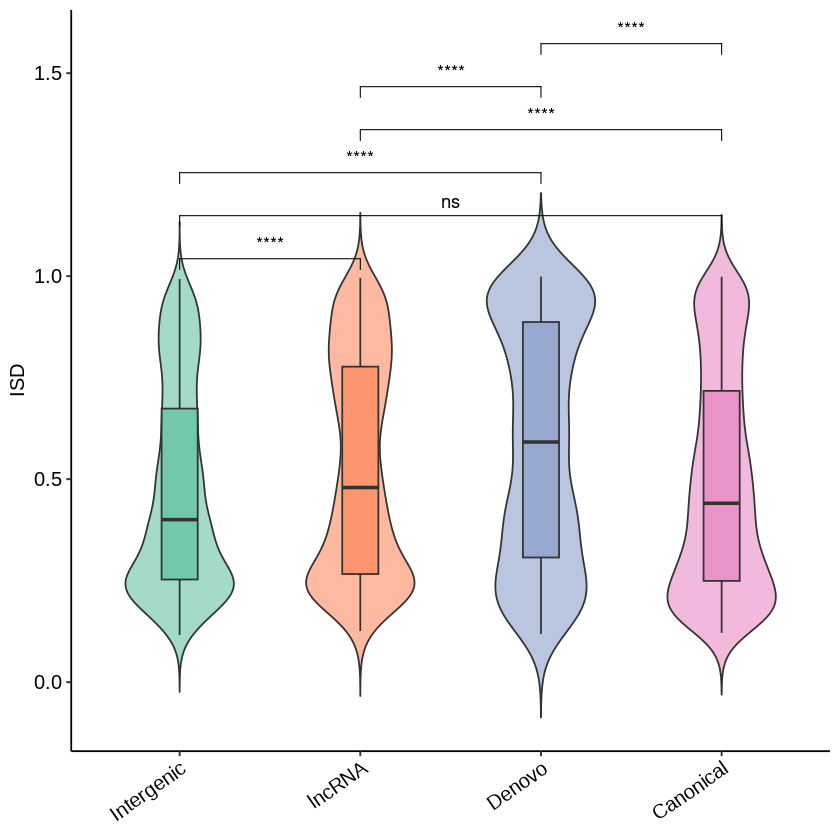

In [246]:
p1 <- violin_plot(all_add_ISD, x = type, y = Avg_ISD, fill = type, y_label = "ISD")
compare(p1, type_pairs)-> p_isd
p_isd

In [247]:
all_add_ISD %>% group_by(type) %>% summarise(mean_1=mean(Avg_ISD))

type,mean_1
<fct>,<dbl>
Intergenic,0.4709980
lncRNA,0.5264468
Denovo,0.5863693
Canonical,0.4921501


In [248]:
head(all_add_ISD$Avg_ISD)

[1] 0.2730 0.5075 0.2002 0.6112 0.7614 0.1649

# 其他比较（不涉及intergenic）

In [252]:
cols <- c("ORF_id","ORF_seq","CDS_seq","N","C","RPF_RPKM","FL_TPM")
rbind(canonical_orfs[,cols],lnc_orfs[,cols],denovo_orfs[,cols]) -> all_orfs_detail
all_orfs_detail %>% distinct(ORF_id,.keep_all = T) -> all_orfs_detail
merge(distinct(all_orfs_with_type,original_id,type),all_orfs_detail,by.x="original_id",by.y="ORF_id") -> all_1
nrow(all_1)
table(all_1$type)

[1] 6061


Canonical    Denovo    lncRNA 
     2500      1141      2420 

In [253]:
LEVELS <- c("lncRNA","Denovo","Canonical")
all_1$type <- factor(all_1$type,levels=LEVELS)
type_names <- as.character(unique(all_1$type))
type_pairs <- combn(type_names, 2, simplify = FALSE)
type_pairs

[[1]]
[1] "lncRNA"    "Canonical"

[[2]]
[1] "lncRNA" "Denovo"

[[3]]
[1] "Canonical" "Denovo"

## 翻译效率

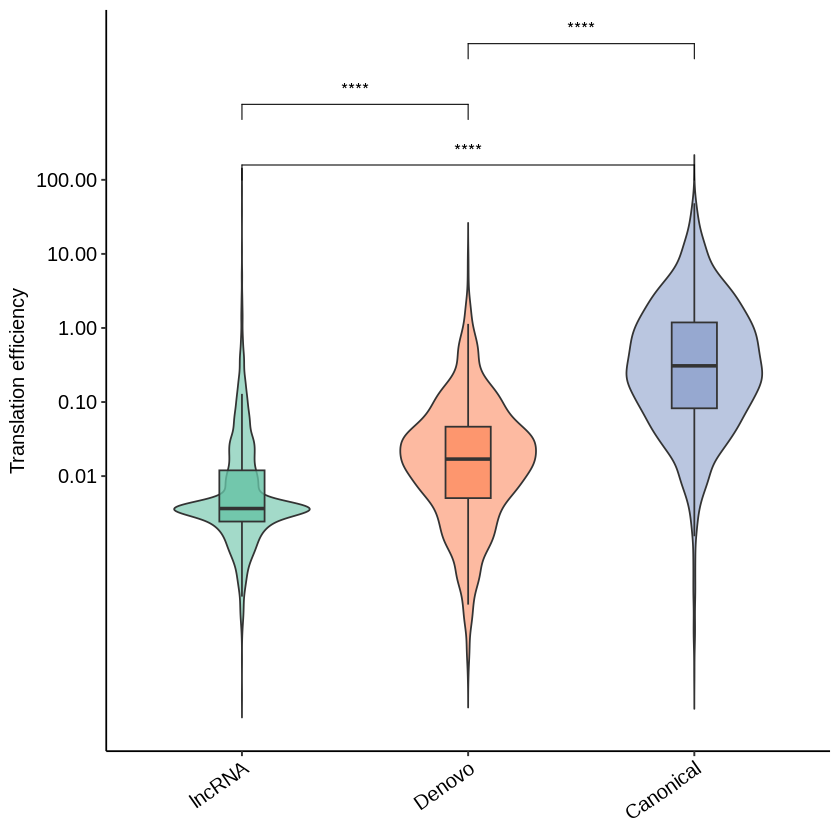

In [254]:
all_1 <- all_1 %>%
    mutate(TE = (RPF_RPKM+0.001)/(FL_TPM+0.001))
y_breaks = c(0.01, 0.1, 1, 10, 100)
p1 <- violin_plot(all_1 , x = type, y = TE, fill = type,y_label = "Translation efficiency")+
scale_y_log10(breaks = y_breaks, labels = sprintf("%.2f", y_breaks))
compare(p1, type_pairs) -> p_te
p_te

## 出核水平

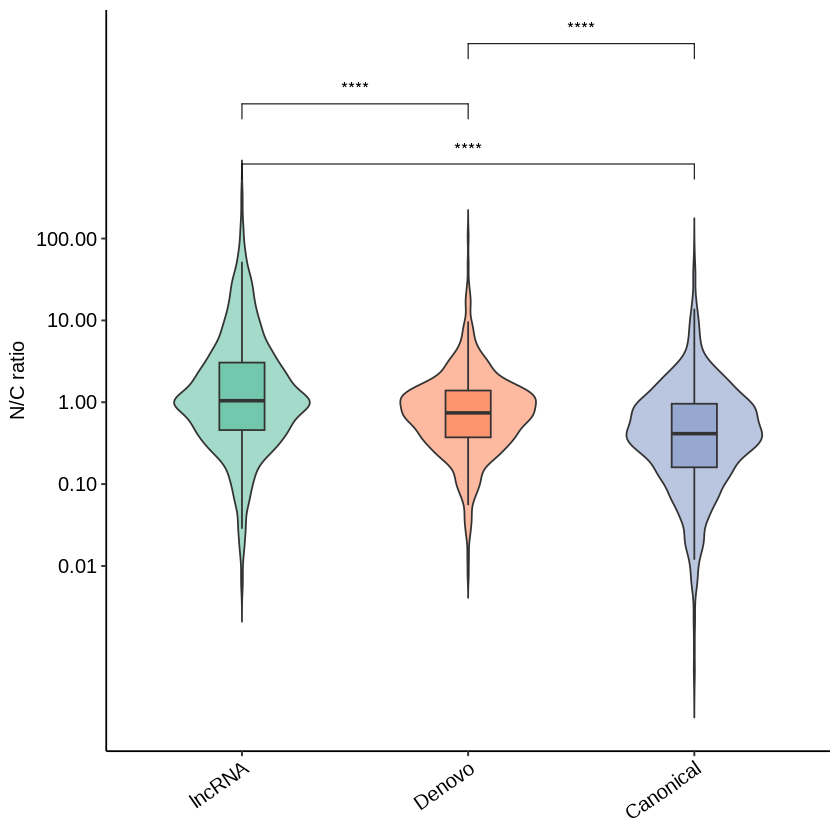

In [255]:
all_1 <- all_1 %>%
    mutate(NC_ratio = (N+0.001)/(C+0.001))
y_breaks = c(0.01, 0.1, 1, 10, 100)
p1 <- violin_plot(all_1, x = type, y = NC_ratio, fill = type,y_label = "N/C ratio")+
scale_y_log10(breaks = y_breaks, labels = sprintf("%.2f", y_breaks))
compare(p1, type_pairs) -> p_nc_ratio
p_nc_ratio

## 转录

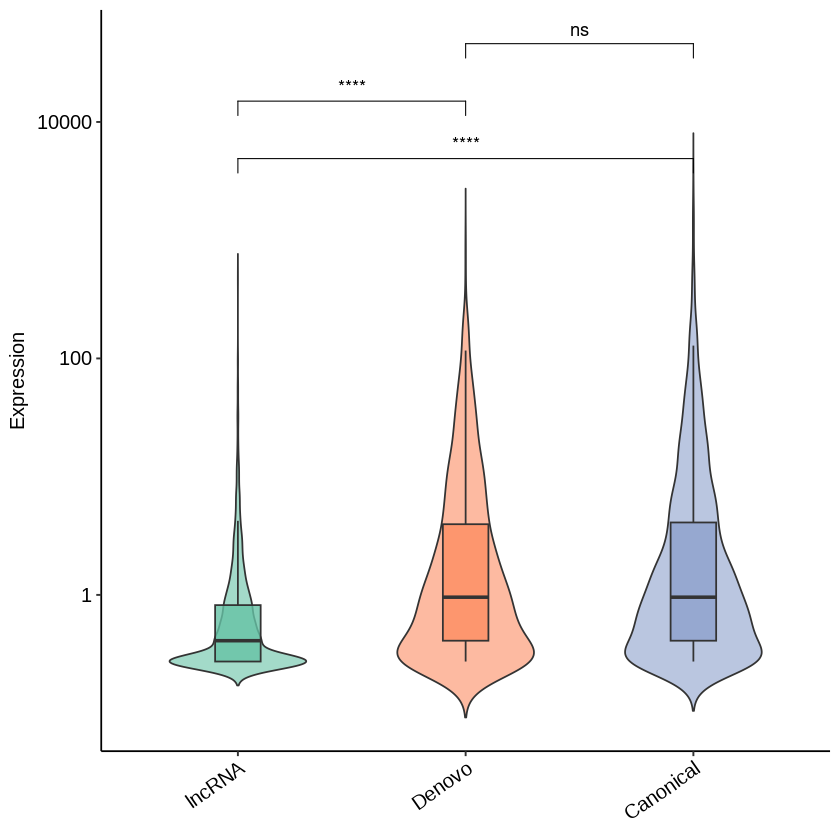

In [256]:
violin_plot(all_1, x = type, y = FL_TPM, fill = type,y_label = "Expression")+
scale_y_log10() -> p
compare(p, type_pairs) -> p_expression
p_expression

# 将除了进化参数之外的结果导出

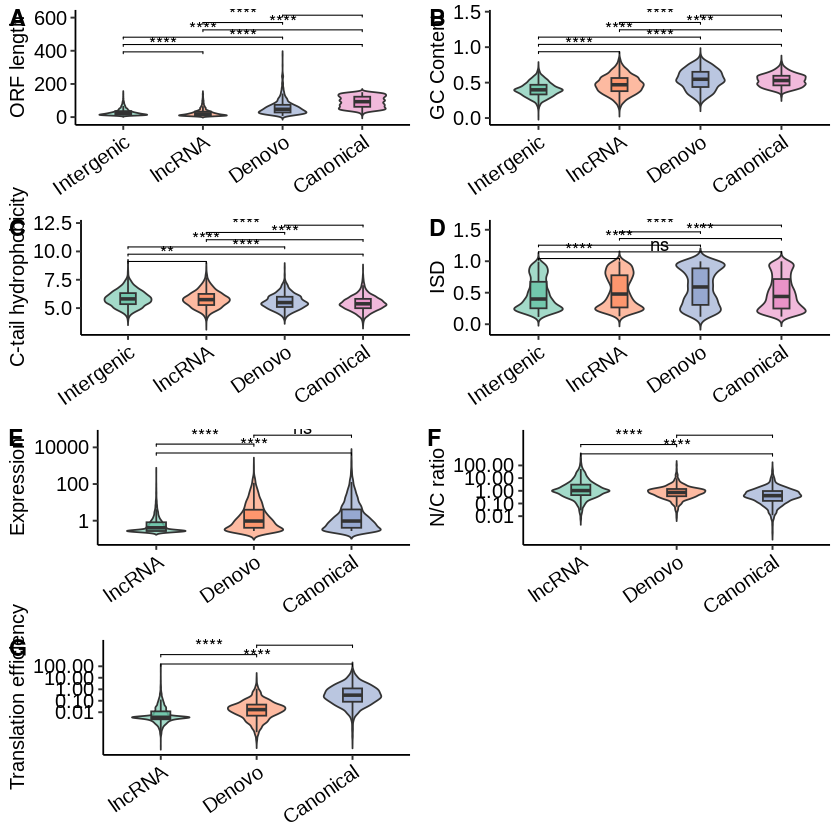

In [257]:
output_path <- "../../figures/new_denovo_list"
combined_plot <- plot_grid(p_orf_length, p_gc, p_hydro_c_tail,p_isd,p_expression,p_nc_ratio,p_te,
                            ncol = 2, nrow = 4, labels = "AUTO")
combined_plot
ggsave(filename = o("combined_plot.pdf"), plot = combined_plot, height = 16, width = 10)

## 统计比较

In [258]:
custom_stat <- function(data, col) {
  data %>% 
    group_by(type) %>% 
    summarise(
      min = min({{ col }}, na.rm = TRUE),
      max = max({{ col }}, na.rm = TRUE),
      median = median({{ col }}, na.rm = TRUE),
      mean = mean({{ col }}, na.rm = TRUE)
    ) %>% arrange(median)
}

# 使用方式
print("ORF_length comparison")
custom_stat(all, ORF_length)
print("GC_content comparison")
custom_stat(all,GC_content )
print("Hydrophobicity_Last15A comparison")
custom_stat(all,Hydrophobicity_Last15A )
print("Avg_ISD comparison")
custom_stat(all_add_ISD,Avg_ISD )
print("TE comparison")
custom_stat(all_1,TE )
print("NC_ratio comparison")
custom_stat(all_1,NC_ratio )
print("Expression comparison")
custom_stat(all_1,FL_TPM )

[1] "ORF_length comparison"


type,min,max,median,mean
<fct>,<int>,<int>,<dbl>,<dbl>
lncRNA,6,147,19,26.54215
Intergenic,10,148,23,29.26280
Denovo,7,375,47,58.36109
Canonical,12,150,93,92.16920


[1] "GC_content comparison"


type,min,max,median,mean
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Intergenic,0.03333333,0.7333333,0.3982611,0.4039322
lncRNA,0.09523810,0.8571429,0.4698912,0.4723934
Canonical,0.29100529,0.8305085,0.5293030,0.5306975
Denovo,0.19047619,0.8924731,0.5472637,0.5440295


[1] "Hydrophobicity_Last15A comparison"


...

type,min,max,median,mean
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
lncRNA,1.080721e-05,72.364699,0.003644952,0.08886958
Denovo,2.241235e-05,8.770159,0.016960547,0.08310829
Canonical,2.217091e-05,70.168980,0.308007464,1.53041532


[1] "NC_ratio comparison"


type,min,max,median,mean
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Canonical,0.0002995762,83.30793,0.4136154,1.125118
Denovo,0.0078304577,116.36380,0.7416902,1.607172
lncRNA,0.0046675031,401.91390,1.0443372,5.593504


[1] "Expression comparison"


type,min,max,median,mean
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
lncRNA,0.273352,480.6903,0.410029,1.523319
Denovo,0.273352,918.3276,0.956734,9.210253
Canonical,0.273352,3074.5320,0.956734,15.431403


# kaks

In [122]:
# fread_c("../../processed/evolution_para/kaks/cano_lnc_intergenic_noncano_sampled/all_kaks_results.summary.txt") -> kaks_1
fread_c("../../processed/evolution_para/kaks/cano_lnc_intergenic_noncano_sampled/all_kaks_merged.txt") -> kaks_1
# fread_c("../../processed/evolution_para/kaks/noncano_sampled/all_kaks_results.summary.txt") -> kaks_2
fread_c("../../processed/evolution_para/kaks/noncano_sampled/all_kaks_merged.txt") -> kaks_2
fread_c("../../processed/evolution_para/kaks/denovo/all_kaks_merged.txt") -> kaks_3
rbind(kaks_1,kaks_2,kaks_3) -> kaks_res
nrow(kaks_res)
head(kaks_res,1)

kaks_res$safe_id <- gsub("\\.prot","",kaks_res$ORF_ID) 
head(kaks_res,1)
n_distinct(kaks_res$safe_id)

[1] 247520

,ORF_ID,Sequence,Method,Ka,Ks,Ka/Ks,P-Value(Fisher),Length,S-Sites,N-Sites,⋯,N-Substitutions,Fold-S-Substitutions(0:2:4),Fold-N-Substitutions(0:2:4),Divergence-Time,Substitution-Rate-Ratio(rTC:rAG:rTA:rCG:rTG:rCA/rCA),GC(1:2:3),ML-Score,AICc,Akaike-Weight,Model
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,⋯,<dbl>,<lgl>,<lgl>,<dbl>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>
1,PB.23209.2__chr2__-__88__1650__1155__1530__canonical__ATG.prot,hg38-HLdipOrd2,NG,0.104674,0.402867,0.259822,1.27394e-06,372,105.873,266.127,⋯,26,NA,NA,0.189541,1:1:1:1:1:1,0.725806(0.741935:0.560484:0.875),NA,NA,NA,NA


,ORF_ID,Sequence,Method,Ka,Ks,Ka/Ks,P-Value(Fisher),Length,S-Sites,N-Sites,⋯,Fold-S-Substitutions(0:2:4),Fold-N-Substitutions(0:2:4),Divergence-Time,Substitution-Rate-Ratio(rTC:rAG:rTA:rCG:rTG:rCA/rCA),GC(1:2:3),ML-Score,AICc,Akaike-Weight,Model,safe_id
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,⋯,<lgl>,<lgl>,<dbl>,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<chr>
1,PB.23209.2__chr2__-__88__1650__1155__1530__canonical__ATG.prot,hg38-HLdipOrd2,NG,0.104674,0.402867,0.259822,1.27394e-06,372,105.873,266.127,⋯,NA,NA,0.189541,1:1:1:1:1:1,0.725806(0.741935:0.560484:0.875),NA,NA,NA,NA,PB.23209.2__chr2__-__88__1650__1155__1530__canonical__ATG


[1] 8838

In [219]:
# Step 1: 按ORF汇总（对不同物种比较取均值）
df_by_orf <- kaks_res %>%
  group_by(safe_id) %>%
  summarise(
    # 位点和替换数取均值
    mean_N_Sites = mean(`N-Sites`, na.rm = TRUE),
    mean_S_Sites = mean(`S-Sites`, na.rm = TRUE),
    mean_N_Substitutions = mean(`N-Substitutions`, na.rm = TRUE),
    mean_S_Substitutions = mean(`S-Substitutions`, na.rm = TRUE),
  )

# 查看结果
df_by_orf %>% head()
df_by_orf %>% nrow()

safe_id,mean_N_Sites,mean_S_Sites,mean_N_Substitutions,mean_S_Substitutions
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
100067954-100153671_588,39.14137,11.85863,1.2500,1.000000
100067954-100153671_607,132.46800,35.53180,1.0000,1.000000
100100172-100149782_210,47.81699,14.88301,2.3125,1.071429
100144671-100156356_16,106.22669,28.77327,6.4000,2.000000
100153779-100375699_1246,76.34780,19.65220,3.0000,1.000000
100192428-100208253_85,57.71782,16.90717,2.8000,1.400000


[1] 8838

In [220]:
merge(df_by_orf,all_orfs_with_type,by.x="safe_id",by.y="safe_id") -> kaks_res_with_type
nrow(kaks_res_with_type)
n_distinct(kaks_res_with_type$safe_id)
head(unique(kaks_res_with_type$safe_id))
distinct(kaks_res_with_type,safe_id,type) %>% count(type)

[1] 6758

[1] 6758

[1] "100067954-100153671_588"  "100067954-100153671_607" 
[3] "100100172-100149782_210"  "100144671-100156356_16"  
[5] "100153779-100375699_1246" "100192428-100208253_85"

type,n
<chr>,<int>
Canonical,1907
Denovo,710
Intergenic,2047
lncRNA,2094


In [222]:
set.seed(42)

result <- kaks_res_with_type %>%
  group_by(type) %>%
  mutate(
    # 随机打乱顺序后分组
    random_order = sample(n()),
    group_id = ceiling(random_order / 5)
  ) %>%
  group_by(type, group_id) %>%
  summarise(
    n_orfs = n(),
    orf_ids = paste(original_id, collapse = ";"),
    sum_N_Substitutions = sum(`mean_N_Substitutions`, na.rm = TRUE),
    sum_N_Sites = sum(`mean_N_Sites`, na.rm = TRUE),
    sum_S_Substitutions = sum(`mean_S_Substitutions`, na.rm = TRUE),
    sum_S_Sites = sum(`mean_S_Sites`, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    weighted_Ka = ifelse(sum_N_Sites > 0, sum_N_Substitutions / sum_N_Sites, NA),
    weighted_Ks = ifelse(sum_S_Sites > 0, sum_S_Substitutions / sum_S_Sites, NA),
    weighted_KaKs = ifelse(!is.na(weighted_Ks) & weighted_Ks > 0, 
                           weighted_Ka / weighted_Ks, NA)
  )

result %>% head()
result %>% nrow()

type,group_id,n_orfs,orf_ids,sum_N_Substitutions,sum_N_Sites,sum_S_Substitutions,sum_S_Sites,weighted_Ka,weighted_Ks,weighted_KaKs
<chr>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Canonical,1,5,PB.15734.11:chr15:+|3|1870:46:421|canonical|ATG;PB.19000.66:chr17:+|18|3135:283:508|canonical|ATG;PB.37535.51:chr5:-|20|2031:317:485|canonical|ATG;PB.40211.1:chr6:-|36|609:385:577|canonical|ATG;PB.49383.8:chr9:-|6|2992:88:490|canonical|ATG,74.92775,984.8182,54.85576,307.4555,0.07608282,0.1784185,0.4264289
Canonical,2,5,PB.21232.15:chr19:-|2|2672:11:278|canonical|ATG;PB.23383.95:chr2:-|12|1936:106:505|canonical|ATG;PB.30829.3:chr3:+|8|1981:57:369|canonical|ATG;PB.41685.227:chr6:-|23|3485:346:682|canonical|ATG;PB.8905.11:chr11:-|3|2473:34:352|canonical|ATG,53.58337,1193.8712,58.05588,380.2164,0.04488203,0.1526917,0.2939390
Canonical,3,5,PB.25653.24:chr2:+|7|2160:109:220|canonical|ATG;PB.26166.25:chr2:+|5|639:62:353|canonical|ATG;PB.3194.15:chr1:+|6|2728:56:380|canonical|ATG;PB.3698.7:chr1:+|24|2915:226:604|canonical|ATG;PB.47829.1:chr8:-|5|3519:54:453|canonical|ATG,41.81480,1141.3177,74.60306,333.8052,0.03663730,0.2234928,0.1639305
Canonical,4,5,PB.11601.74:chr12:-|2|2499:11:314|canonical|ATG;PB.21791.10:chr19:-|9|1384:145:472|canonical|ATG;PB.23898.7:chr2:-|19|3578:248:389|canonical|ATG;PB.35978.60:chr4:-|7|2338:90:456|canonical|ATG;PB.55675.2:chrX:-|1|617:18:450|canonical|ATG,36.17588,1146.8331,42.12051,368.2576,0.03154416,0.1143779,0.2757890
Canonical,5,5,PB.10179.9:chr12:+|18|3356:350:563|canonical|ATG;PB.13609.1:chr14:+|9|1039:274:727|canonical|ATG;PB.22005.75:chr19:-|7|656:121:367|canonical|ATG;PB.27090.3:chr2:-|2|953:23:275|canonical|ATG;PB.49603.3:chr9:-|13|693:150:534|canonical|ATG,56.08104,1157.3128,71.15578,363.6806,0.04845798,0.1956546,0.2476710
Canonical,6,5,PB.19316.14:chr17:-|8|2061:141:555|canonical|ATG;PB.22690.101:chr19:-|14|2170:233:404|canonical|ATG;PB.31126.33:chr3:+|8|2394:114:270|canonical|ATG;PB.4583.1:chr10:+|26|1572:396:846|canonical|ATG;PB.7473.1:chr11:+|14|701:177:621|canonical|ATG,46.15993,1250.5736,72.37612,364.5436,0.03691100,0.1985390,0.1859131


[1] 1353

## 作图

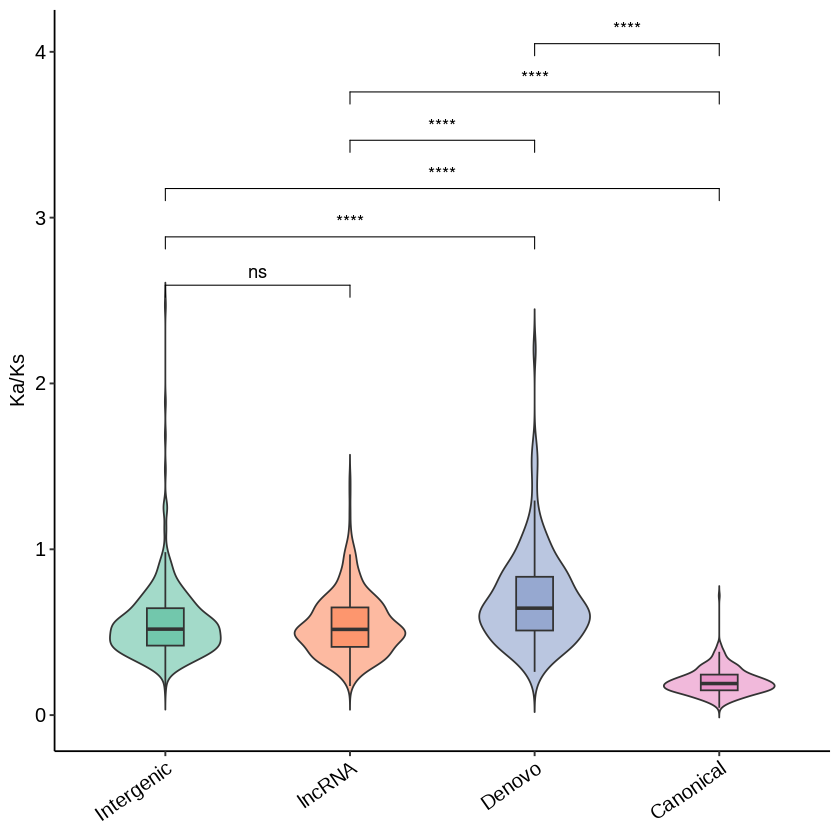

In [223]:
LEVELS <- c("Intergenic","lncRNA","Denovo","Canonical")
type_pairs <- combn(LEVELS, 2, simplify = FALSE)
result$type <- factor(result$type,levels=LEVELS)
violin_plot_1(result, x = type, y = weighted_KaKs, fill = type,y_label = "Ka/Ks") ->p
compare(p, type_pairs) -> p_kaks
p_kaks
ggsave(filename = o("kaks.pdf"), plot = p_kaks, height = 5, width = 5)

# pnps

In [172]:
fread_c("../../processed/pnps/orf_syn_nonsyn.strict.tsv") -> orf_syn_nonsyn_1
fread_c("../../processed/pnps_denovo/orf_syn_nonsyn.strict.tsv") -> orf_syn_nonsyn_2
rbind(orf_syn_nonsyn_1,orf_syn_nonsyn_2) -> orf_syn_nonsyn
head(orf_syn_nonsyn,1)
tail(orf_syn_nonsyn,1)

,ORF_ID,syn_sites,nonsyn_sites
,<chr>,<int>,<int>
1,99309590-99464377_203,0,1


,ORF_ID,syn_sites,nonsyn_sites
,<chr>,<int>,<int>
13552,PB.10666.2:chr12:+|13|1424:135:900|noncoding|ATG,4,6


In [204]:
nrow(orf_syn_nonsyn)
n_distinct(orf_syn_nonsyn)
orf_syn_nonsyn %>% distinct(ORF_ID,syn_sites,nonsyn_sites) %>% nrow()
orf_syn_nonsyn %>% distinct(ORF_ID,syn_sites,nonsyn_sites) -> orf_syn_nonsyn_unique

[1] 13552

[1] 13323

[1] 13323

In [205]:
merge(all_orfs_with_type,orf_syn_nonsyn_unique,by.x="original_id",by="ORF_ID") -> all_orfs_pnps
table(all_orfs_pnps$type)
all_orfs_pnps %>% group_by(type) %>% 
summarise(syn_sites_sum=sum(syn_sites),nonsyn_sites_sum=sum(nonsyn_sites)) %>% mutate(nonsyn_sites_sum/syn_sites_sum*1/2)


 Canonical     Denovo Intergenic     lncRNA 
      2500       1141       2500       2420 

type,syn_sites_sum,nonsyn_sites_sum,nonsyn_sites_sum/syn_sites_sum * 1/2
<chr>,<int>,<int>,<dbl>
Canonical,3207,4585,0.7148425
Denovo,1160,2474,1.0663793
Intergenic,1153,3238,1.4041631
lncRNA,953,2288,1.2004197


In [208]:
fread_c("/home/user/data3/lit/project/sORFs/10-feature-egi/processed/pnps/orfs_fa/all_kaks_results.txt") -> pnps_back

In [209]:
head(pnps_back)
pnps_back %>% dplyr::select(orf_id,`S-Sites`,`N-Sites`) -> pnps_back_selected
nrow(pnps_back_selected)
n_distinct(pnps_back_selected$orf_id)

,orf_id,Species_pair,Ka,Ks,Ka/Ks,S-Substitutions,N-Substitutions,S-Sites,N-Sites
,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>
1,PB.18548.1:chr17:+|48|1683:845:959|noncoding|TTG,human_1-human_2,NA,NA,NA,NA,NA,29.12040,81.8796
2,PB.36878.2:chr5:-|63|1640:648:738|noncoding|GTG,human_1-human_2,NA,NA,NA,NA,NA,22.78570,64.2143
3,PB.10685.1:chr12:+|34|1476:347:398|noncoding|ACG,human_1-human_2,NA,NA,NA,NA,NA,12.68570,35.3143
4,PB.31151.2:chr3:+|49|1071:646:676|noncoding|CTG,human_1-human_2,NA,NA,NA,NA,NA,5.53846,21.4615
5,PB.31158.8:chr3:+|135|2335:2190:2214|noncoding|TTG,human_1-human_2,NA,NA,NA,NA,NA,5.08065,15.9194
6,PB.28136.1:chr20:+|40|1187:785:812|noncoding|TTG,human_1-human_2,NA,NA,NA,NA,NA,5.82857,18.1714


[1] 13321

[1] 13321

In [211]:
nrow(all_orfs_pnps_1)
all_orfs_pnps_1 %>% na.omit() %>% nrow()

[1] 8561

[1] 8561

In [212]:
mean(all_orfs_pnps_1$`S-Sites`)
mean(all_orfs_pnps_1$`N-Sites`)

[1] 36.18597

[1] 116.0399

## 方法一

In [216]:
set.seed(42)

result <- all_orfs_pnps %>% mutate(ps=syn_sites) %>% mutate(pn=nonsyn_sites/2) %>% 
  group_by(type) %>%
  mutate(
    # 随机打乱顺序后分组
    random_order = sample(n()),
    group_id = ceiling(random_order / 5)
  ) %>%
  group_by(type, group_id) %>%
  summarise(
    n_orfs = n(),
    orf_ids = paste(original_id, collapse = ";"),
    pn = sum(pn, na.rm = TRUE),
    ps = sum(ps, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    weighted_pnps = ifelse(!is.na(ps) & ps > 0, 
                           pn / ps, NA)
  )

result %>% head()
result %>% nrow()
result %>% na.omit() %>% filter(weighted_pnps>0) %>% nrow()

type,group_id,n_orfs,orf_ids,pn,ps,weighted_pnps
<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
Canonical,1,5,PB.12455.7:chr13:-|5|790:71:365|canonical|ATG;PB.16194.3:chr15:+|4|2483:107:428|canonical|ATG;PB.27599.5:chr20:+|5|483:48:333|canonical|ATG;PB.28762.6:chr21:-|9|2146:155:509|canonical|ATG;PB.8199.18:chr11:-|57|1894:894:1197|canonical|ATG,2,4,0.5000000
Canonical,2,5,PB.17291.1:chr16:+|13|3320:177:444|canonical|ATG;PB.19437.4:chr17:+|11|1498:101:323|canonical|ATG;PB.2741.44:chr1:-|6|1223:143:509|canonical|ATG;PB.39881.39:chr5:+|8|2424:160:445|canonical|ATG;PB.50288.6:chr9:+|3|943:68:248|canonical|ATG,2,12,0.1666667
Canonical,3,5,PB.20999.1:chr18:+|14|1899:183:348|canonical|ATG;PB.21270.96:chr19:+|31|726:310:709|canonical|ATG;PB.2830.7:chr1:+|5|465:36:282|canonical|ATG;PB.29314.12:chr22:+|7|1847:277:403|canonical|ATG;PB.40515.6:chr6:+|18|1995:270:543|canonical|ATG,3,7,0.4285714
Canonical,4,5,PB.10980.2:chr12:+|3|2949:29:404|canonical|ATG;PB.18028.38:chr16:+|14|3484:213:396|canonical|ATG;PB.19690.15:chr17:+|5|589:43:451|canonical|ATG;PB.26506.5:chr2:+|14|2017:258:636|canonical|ATG;PB.37332.36:chr5:+|3|4790:73:244|canonical|ATG,5,9,0.5555556
Canonical,5,5,PB.11574.7:chr12:+|4|1872:33:300|canonical|ATG;PB.18436.2:chr16:+|5|2202:149:527|canonical|ATG;PB.21651.2:chr19:-|8|540:74:488|canonical|ATG;PB.44751.2:chr7:-|8|3025:144:366|canonical|ATG;PB.54763.2:chrX:+|15|1173:253:556|canonical|ATG,6,9,0.6666667
Canonical,6,5,PB.16363.17:chr15:-|4|2736:59:296|canonical|ATG;PB.18948.21:chr17:+|1|1703:21:183|canonical|ATG;PB.23596.205:chr2:-|4|719:116:545|canonical|ATG;PB.43479.49:chr7:+|17|3138:243:366|canonical|ATG;PB.54027.19:chrX:+|8|5140:107:548|canonical|ATG,6,6,1.0000000


[1] 1713

[1] 1489

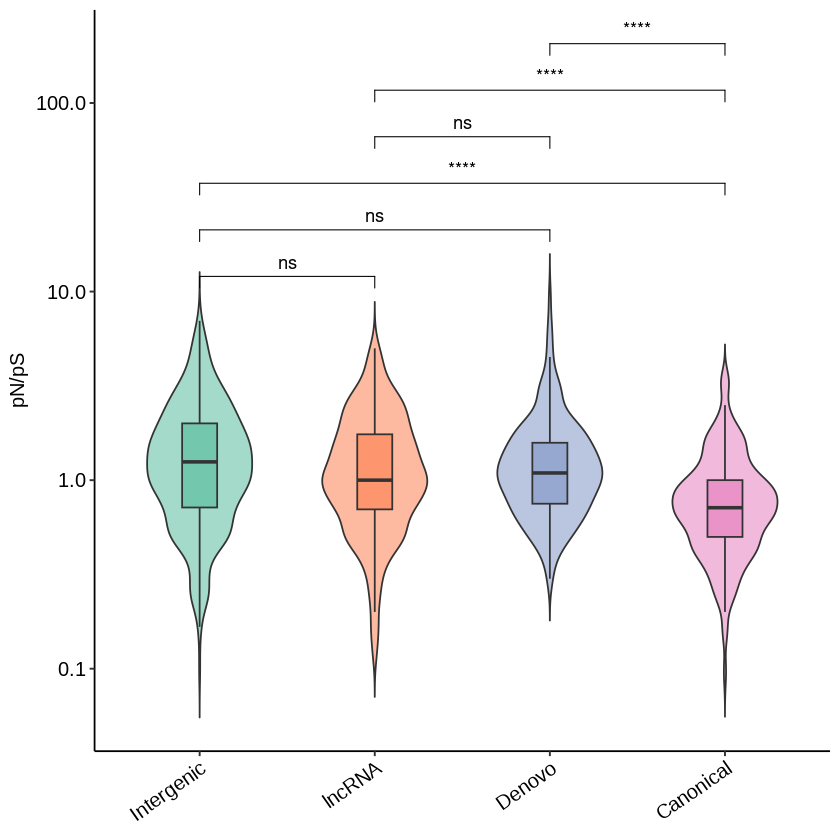

In [218]:
LEVELS <- c("Intergenic","lncRNA","Denovo","Canonical")
type_pairs <- combn(LEVELS, 2, simplify = FALSE)
result$type <- factor(result$type,levels=LEVELS)
violin_plot_1(result %>% na.omit() %>% filter(weighted_pnps>0), x = type, y = weighted_pnps, fill = type,y_label = "pN/pS")+
scale_y_log10() -> p
compare(p,type_pairs) -> p_pnps
p_pnps
ggsave(filename = o("pnps.pdf"), plot = p_pnps, height = 5, width = 5)

## 方法二

In [213]:
set.seed(42)
# syn_sites	nonsyn_sites	S-Sites	N-Sites
result <- all_orfs_pnps_1 %>%
  group_by(type) %>%
  mutate(
    # 随机打乱顺序后分组
    random_order = sample(n()),
    group_id = ceiling(random_order / 5)
  ) %>%
  group_by(type, group_id) %>%
  summarise(
    n_orfs = n(),
    orf_ids = paste(original_id, collapse = ";"),
    sum_nonsyn_sites = sum(`nonsyn_sites`, na.rm = TRUE),
    sum_N_Sites = sum(`N-Sites`, na.rm = TRUE),
    sum_syn_sites = sum(`syn_sites`, na.rm = TRUE),
    sum_S_Sites = sum(`S-Sites`, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    weighted_pN = ifelse(sum_N_Sites > 0, sum_nonsyn_sites / sum_N_Sites, NA),
    weighted_pS = ifelse(sum_S_Sites > 0, sum_syn_sites / sum_S_Sites, NA),
    weighted_pnps = ifelse(!is.na(weighted_pS) & weighted_pS > 0, 
                           weighted_pN / weighted_pS, NA)
  )

result %>% head()
result %>% nrow()

type,group_id,n_orfs,orf_ids,sum_nonsyn_sites,sum_N_Sites,sum_syn_sites,sum_S_Sites,weighted_pN,weighted_pS,weighted_pnps
<chr>,<dbl>,<int>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Canonical,1,5,PB.12455.7:chr13:-|5|790:71:365|canonical|ATG;PB.16194.3:chr15:+|4|2483:107:428|canonical|ATG;PB.27599.5:chr20:+|5|483:48:333|canonical|ATG;PB.28762.6:chr21:-|9|2146:155:509|canonical|ATG;PB.8199.18:chr11:-|57|1894:894:1197|canonical|ATG,4,1172.8740,4,369.1264,0.003410426,0.01083640,0.3147196
Canonical,2,5,PB.17291.1:chr16:+|13|3320:177:444|canonical|ATG;PB.19437.4:chr17:+|11|1498:101:323|canonical|ATG;PB.2741.44:chr1:-|6|1223:143:509|canonical|ATG;PB.39881.39:chr5:+|8|2424:160:445|canonical|ATG;PB.50288.6:chr9:+|3|943:68:248|canonical|ATG,4,998.9340,12,306.0652,0.004004269,0.03920733,0.1021306
Canonical,3,5,PB.20999.1:chr18:+|14|1899:183:348|canonical|ATG;PB.21270.96:chr19:+|31|726:310:709|canonical|ATG;PB.2830.7:chr1:+|5|465:36:282|canonical|ATG;PB.29314.12:chr22:+|7|1847:277:403|canonical|ATG;PB.40515.6:chr6:+|18|1995:270:543|canonical|ATG,6,889.0305,7,304.9687,0.006748925,0.02295318,0.2940301
Canonical,4,5,PB.10980.2:chr12:+|3|2949:29:404|canonical|ATG;PB.18028.38:chr16:+|14|3484:213:396|canonical|ATG;PB.19690.15:chr17:+|5|589:43:451|canonical|ATG;PB.26506.5:chr2:+|14|2017:258:636|canonical|ATG;PB.37332.36:chr5:+|3|4790:73:244|canonical|ATG,10,1156.2140,9,343.7852,0.008648918,0.02617914,0.3303744
Canonical,5,5,PB.11574.7:chr12:+|4|1872:33:300|canonical|ATG;PB.18436.2:chr16:+|5|2202:149:527|canonical|ATG;PB.21651.2:chr19:-|8|540:74:488|canonical|ATG;PB.44751.2:chr7:-|8|3025:144:366|canonical|ATG;PB.54763.2:chrX:+|15|1173:253:556|canonical|ATG,12,1206.1780,9,362.8219,0.009948780,0.02480556,0.4010706
Canonical,6,5,PB.16363.17:chr15:-|4|2736:59:296|canonical|ATG;PB.18948.21:chr17:+|1|1703:21:183|canonical|ATG;PB.23596.205:chr2:-|4|719:116:545|canonical|ATG;PB.43479.49:chr7:+|17|3138:243:366|canonical|ATG;PB.54027.19:chrX:+|8|5140:107:548|canonical|ATG,12,1049.4769,6,327.5235,0.011434268,0.01831930,0.6241652


[1] 1713

In [214]:
table(result$type)


 Canonical     Denovo Intergenic     lncRNA 
       500        229        500        484 

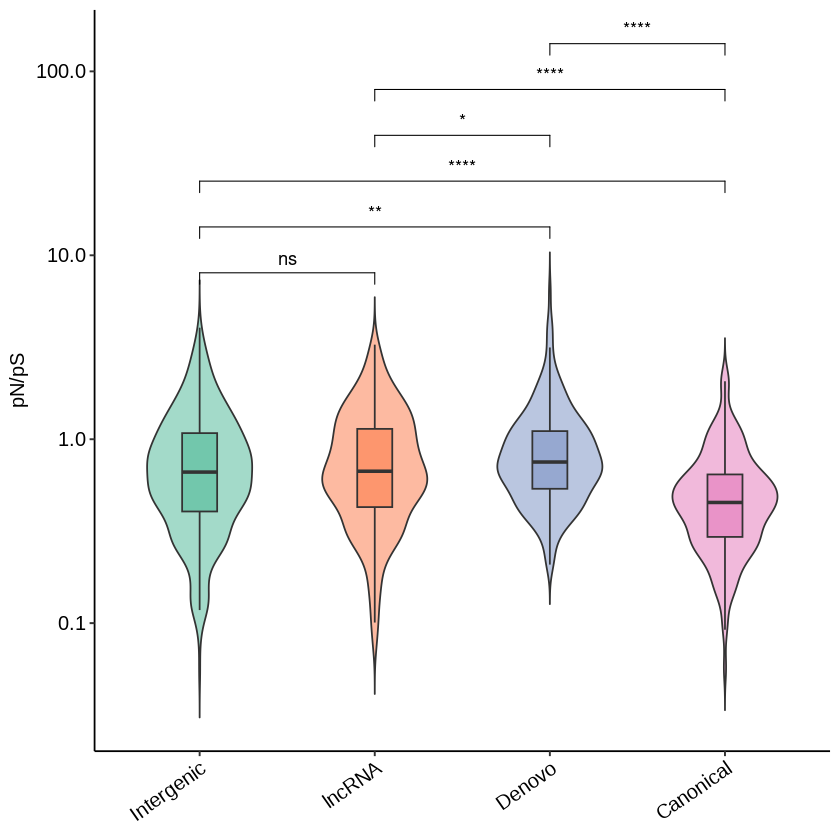

In [215]:
LEVELS <- c("Intergenic","lncRNA","Denovo","Canonical")
type_pairs <- combn(LEVELS, 2, simplify = FALSE)
result$type <- factor(result$type,levels=LEVELS)
violin_plot_1(result %>% na.omit() %>% filter(weighted_pnps>0), x = type, y = weighted_pnps, fill = type,y_label = "pN/pS")+
scale_y_log10() -> p
compare(p,type_pairs) -> p_pnps
p_pnps
ggsave(filename = o("pnps_normalization.pdf"), plot = p_pnps, height = 5, width = 5)

## 方法三

In [69]:
all_orfs_pnps %>% filter(syn_sites >0 & nonsyn_sites >0)  -> all_orfs_pnps_filtered
nrow(all_orfs_pnps_filtered)
all_orfs_pnps_filtered %>% mutate(pnps_raw=nonsyn_sites/syn_sites*1/2) -> all_orfs_pnps_filtered

[1] 2875

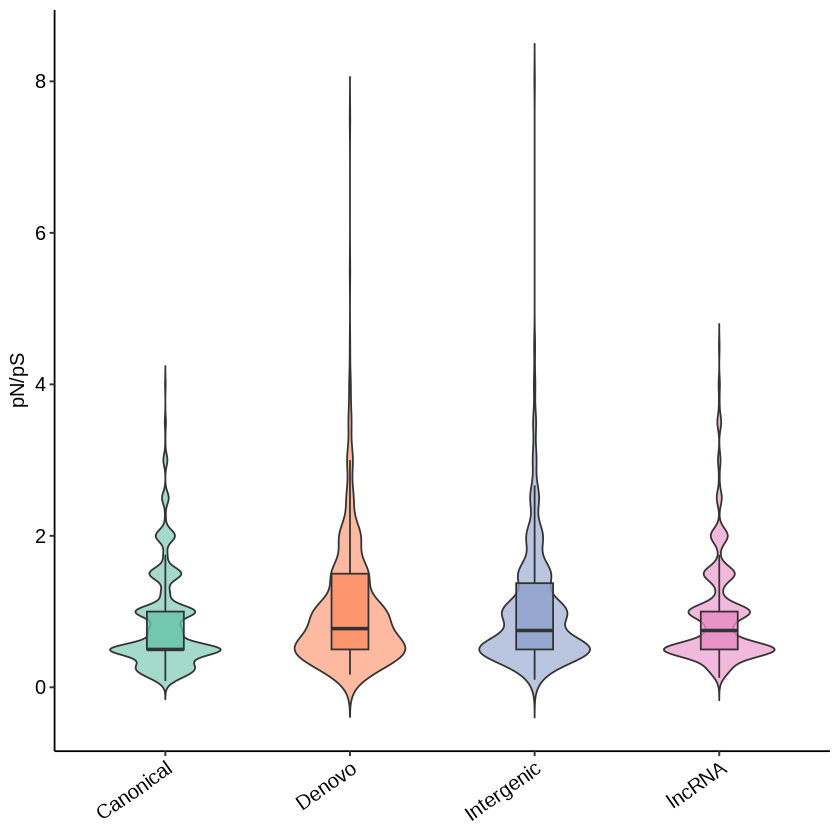

In [71]:
violin_plot_1(all_orfs_pnps_filtered, x = type, y = pnps_raw, fill = type,y_label = "pN/pS")
# +
# coord_cartesian(ylim = c(0, 1))

## 新的计算方法

### 准备

In [355]:
# denovo_genes.older = read_tsv("/home/user/data3/rbase/denovo_tumor/denovo_genes/gentree/denovo_genes.older.txt")
# denovo_genes.older.cds_seq = read_tsv("/home/user/data3/rbase/denovo_tumor/denovo_genes/gentree/denovo_genes.older.cds.txt",col_names = c("Transcript ID","CDS Sequence")) %>%
#   right_join(denovo_genes.older)
# denovo.cds_seq = read_tsv("/home/user/data3/rbase/denovo_tumor/denovo_genes/100_denovo_gene_list/100_denovo_genes.cds.txt") %>%
#   ## add gene age
#   inner_join(denovo_genes.hc.hominoid %>% select(`Gene ID`,`Protein Age`), by=c("Gene ID")) %>%
#   # add older de novo genes
#   bind_rows(denovo_genes.older.cds_seq %>%
#               select(`Gene ID`, `CDS Sequence`, `Protein Age`)) %>%
#   mutate(Group_age = if_else((!`Protein Age` %in% c("human", "hominoid")), "Older", str_to_title(`Protein Age`))) %>%
#   # human or hominoid-specific genes are proved to translated
#   filter((Group_age %in% c("Human","Hominoid") & `Gene ID` %in% denovo_genes.hc.hominoid$`Gene ID`) |
#            Group_age =="Older" ) %>%
#   dplyr::rename(Age=`Protein Age`)
# pc_genes.age = read_tsv("/home/user/data3/rbase/denovo_tumor/denovo_genes/all_ORFs/coding_ORFs/pc_ORFs.shuffle.genepred.txt",
#                     col_names = c("ID","Chro","Starnd","Gene start","Gene end","CDS start","CDS end","Exon num","Exon starts","Exon ends","Protein Age"))
# pc_genes.orf_seq = read_tsv("/home/user/data3/rbase/denovo_tumor/denovo_genes/all_ORFs/coding_ORFs/pc_ORFs.shuffle.fa.txt") %>%
#   left_join(pc_genes.age %>% select(`ID`,`Protein Age`), join_by("Gene ID"=="ID")) %>%
#   mutate(Group_age=case_when(
#     `Protein Age` %in% c(3,4,5,6,7,8,9) ~ "Older",
#     `Protein Age` %in% c(10,11,12,13) ~ "Hominoid",
#     `Protein Age` == 14 ~ "Human",
#     .default = NA
#   )) %>%
#   dplyr::mutate(Age=as.character(`Protein Age`)) %>% 
#   select(-`Protein Age`)
# lnc_genes.gt30.orf_seq = read_tsv("/home/user/data3/rbase/denovo_tumor/denovo_genes/all_ORFs/lncRNA/lncRNA_ORFs.gt30.shuffle.fa.txt") %>%
#   mutate(Group_age="lncRNA", Age=NA)
# up_genes.gt30.orf_seq = read_tsv("/home/user/data3/rbase/denovo_tumor/denovo_genes/all_ORFs/uORFs/uORFs.gt30.shuffle.fa.txt") %>%
#   mutate(Group_age="5' UTR", Age=NA)
# down_genes.gt30.orf_seq = read_tsv("/home/user/data3/rbase/denovo_tumor/denovo_genes/all_ORFs/dORFs/dORFs.gt30.shuffle.fa.txt") %>%
#   mutate(Group_age="3' UTR", Age=NA)
# intron_genes.gt30.orf_seq = read_tsv("/home/user/data3/rbase/denovo_tumor/denovo_genes/all_ORFs/intron_ORFs/intron_ORFs.gt30.shuffle.fa.txt") %>%
#   mutate(Group_age="Intron", Age=NA)
# inter_genes.gt30.orf_seq = read_tsv("/home/user/data3/rbase/denovo_tumor/denovo_genes/all_ORFs/intergenic_ORFs/intergenic_ORFs.gt30.shuffle.fa.txt") %>%
#   mutate(Group_age="Intergenic", Age=NA)
# inter_genes.random.orf_seq = read_tsv("/home/user/data3/rbase/denovo_tumor/denovo_genes/all_ORFs/intergenic_random_seq/intergenic_random.fa.txt") %>%
#   mutate(Group_age="Random", Age=NA)

# # all
# all.gt30.orf_seq = denovo.cds_seq %>% mutate(Group="De novo") %>%
#   rbind(pc_genes.orf_seq %>% mutate(Group="Canonical")) %>%
#   rbind(lnc_genes.gt30.orf_seq %>% mutate(Group="lncRNA")) %>%
#   rbind(up_genes.gt30.orf_seq %>% mutate(Group="5' UTR")) %>%
#   rbind(down_genes.gt30.orf_seq %>% mutate(Group="3' UTR")) %>%
#   rbind(intron_genes.gt30.orf_seq %>% mutate(Group="Intron")) %>%
#   rbind(inter_genes.gt30.orf_seq %>% mutate(Group="Intergenic")) %>%
#   rbind(inter_genes.random.orf_seq %>% mutate(Group="Random")) %>%
#   relocate(`Gene ID`,Group) %>%
#   mutate(`Gene ID` = gsub(`Gene ID`, pattern=" \\[[0-9]+ - [0-9]+\\]", replacement=""))
# create_path("../../processed/seve_list_compare_v2/")
# write_tsv(all.gt30.orf_seq,"../../processed/seve_list_compare_v2/all.gt30.orf_seq.tsv")

### ORF类型以及背景的N sites以及S sites计算

#### 准备

In [315]:
# 从之前的结果中导入新de novo基因和类型的对照
table(all_orfs_with_type$type)
all_orfs_with_type %>% filter(type=="Denovo") -> denovo_new
head(denovo_new,1)
nrow(denovo_new)


 Canonical     Denovo Intergenic     lncRNA 
      2500       1141       2500       2420 

,original_id,type,safe_id
,<chr>,<chr>,<chr>
1,PB.10161.28:chr12:+|160|4126:2138:2345|dORF|ATG,Denovo,PB.10161.28_chr12___160_4126_2138_2345_dORF_ATG


[1] 1141

In [364]:
all.gt30.orf_seq = read.csv("/home/user/data3/rbase/denovo_tumor/denovo_genes/all_ORFs/all.gt30.orf_seq.tsv",sep = '\t')
head(all.gt30.orf_seq,1) %>% print()
nrow(all.gt30.orf_seq)
all.gt30.orf_seq %>% distinct(Gene.ID,.keep_all = T) -> tmp
head(tmp,1)
# 这里面的de novo和实际上的100个de novo有点对不上，所以去掉
tmp %>% filter(Group!="De novo")-> tmp_1
table(tmp_1$Group)
tmp_1 -> all.gt30.orf_seq

          Gene.ID   Group
1 ENSG00000100433 De novo
                                                                                                                                                                                                                                                                                                                                                                                                                                                        CDS.Sequence
1 ATGTTTCGATTTCACACAAAGAAAGAGCACACGTCCACCATCTTCAGTGGGGGCTGTCTTTTGCTTCACTGGCAAGCAGGCACTGAATTTTTCTTGCATGACAAATCTGGAGGTTTACTGGTGAGAGAGCCAATGGGCATTTTTTCCTGGAAAGAGTACAGCTCCATACCCAGTCCTAACCCAACAGTGATATTTATCACTTTGGGGCAGGGCTGTATAGAGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGCGGGTTGGGGTGGTGTTGGGCCATCTCTGGCCTGTTACTAAGGTAACTAGGACTATTTGTGTTCCAGCAGTCATAGCCTGTGATTGTGGGTGCATCAGTTCTCTGCCTAGATCTCTTGTTACCTTGTCTGCACATCAAGGGAGGGAGTTGAGCACAGATACTTGTCAAGGGCCATTGTAG
    Age Group_age
1 human     Human


[1] 27696

,Gene.ID,Group,CDS.Sequence,Age,Group_age
,<chr>,<chr>,<chr>,<chr>,<chr>
1,ENSG00000100433,De novo,ATGTTTCGATTTCACACAAAGAAAGAGCACACGTCCACCATCTTCAGTGGGGGCTGTCTTTTGCTTCACTGGCAAGCAGGCACTGAATTTTTCTTGCATGACAAATCTGGAGGTTTACTGGTGAGAGAGCCAATGGGCATTTTTTCCTGGAAAGAGTACAGCTCCATACCCAGTCCTAACCCAACAGTGATATTTATCACTTTGGGGCAGGGCTGTATAGAGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGCGGGTTGGGGTGGTGTTGGGCCATCTCTGGCCTGTTACTAAGGTAACTAGGACTATTTGTGTTCCAGCAGTCATAGCCTGTGATTGTGGGTGCATCAGTTCTCTGCCTAGATCTCTTGTTACCTTGTCTGCACATCAAGGGAGGGAGTTGAGCACAGATACTTGTCAAGGGCCATTGTAG,human,Human



    3' UTR     5' UTR  Canonical Intergenic     Intron     lncRNA     Random 
      4000       4000       3270       4000       4000       4000       4000 

In [379]:
# 首先合并类型
denovo_new$Age  <- NA
denovo_new$Group_age  <- NA
head(denovo_new,1)
denovo_new$type <- "Denovo_new"
denovo_new %>% select(original_id,type,Age,Group_age) -> denovo_new_selected

denovo_v2 <- fread_c("/home/user/data3/rbase/small_peptide/denovo_genes/denovo_genes.primates.tsv") %>% filter(lineage=="human" | lineage=="hominoid")
head(denovo_v2,1)
nrow(denovo_v2)
nrow(denovo_new_selected)
filter(denovo_new_selected,original_id %in% denovo_v2$orf_id) -> denovo_new_selected_fil
nrow(denovo_new_selected_fil)

all.gt30.orf_seq %>% select(Gene.ID,Group,Age,Group_age) %>% rename(original_id=Gene.ID,type=Group) -> all.gt30.orf_seq.selected
head(all.gt30.orf_seq.selected,1)
rbind(all.gt30.orf_seq.selected,denovo_new_selected_fil) -> all.id.type.0
table(all.id.type.0$type)

denovo.cds_seq <- read_tsv("/home/user/data3/rbase/denovo_tumor/denovo_genes/100_denovo_gene_list/100_denovo_genes.cds.txt") 
denovo.cds_seq %>% select(1) -> denovo.cds_seq
colnames(denovo.cds_seq) <- c("original_id")
denovo.cds_seq$type <- "Denovo_old"
denovo.cds_seq$Age  <- NA
denovo.cds_seq$Group_age  <- NA
head(denovo.cds_seq)
rbind(all.id.type.0,denovo.cds_seq) -> all.id.type
head(all.id.type,1)
table(all.id.type$type)
count(all.id.type,type)

,original_id,type,safe_id,Age,Group_age
,<chr>,<chr>,<chr>,<lgl>,<lgl>
1,PB.10161.28:chr12:+|160|4126:2138:2345|dORF|ATG,Denovo_new,PB.10161.28_chr12___160_4126_2138_2345_dORF_ATG,NA,NA


,orf_id,lineage,orig_age,syn_age
,<chr>,<chr>,<chr>,<chr>
1,PB.111.1:chr1:-|244|4307:2825:3008|dORF|ATG,hominoid,primatomorpha,placentalia


[1] 1055

[1] 1141

[1] 1019

...

Rows: 100 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): Gene ID, CDS Sequence

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


original_id,type,Age,Group_age
<chr>,<chr>,<lgl>,<lgl>
ENSG00000100433,Denovo_old,NA,NA
ENSG00000120742,Denovo_old,NA,NA
ENSG00000125462,Denovo_old,NA,NA
ENSG00000144057,Denovo_old,NA,NA
ENSG00000145063,Denovo_old,NA,NA
ENSG00000149443,Denovo_old,NA,NA


,original_id,type,Age,Group_age
,<chr>,<chr>,<chr>,<chr>
1,ENST00000274137.10:chr5:+|1|518:12:387|canonical|ATG,Canonical,2,NA



    3' UTR     5' UTR  Canonical Denovo_new Denovo_old Intergenic     Intron 
      4000       4000       3270       1019        100       4000       4000 
    lncRNA     Random 
      4000       4000 

type,n
<chr>,<int>
3' UTR,4000
5' UTR,4000
Canonical,3270
Denovo_new,1019
Denovo_old,100
Intergenic,4000
Intron,4000
Random,4000
lncRNA,4000


In [380]:
# 从之前的结果中导入新de novo基因和对应的N sites和S sites
fread_c("../../processed/pnps/orfs_fa/all_kaks_results.txt") -> S_N_sites_contain_new_denovo
S_N_sites_contain_new_denovo %>% filter(orf_id %in% denovo_new$original_id) -> S_N_sites_new_denovo
head(S_N_sites_new_denovo,1)
# 部分序列没有N sites和S sites
# setdiff(denovo_new$original_id,S_N_sites_new_denovo$orf_id)

,orf_id,Species_pair,Ka,Ks,Ka/Ks,S-Substitutions,N-Substitutions,S-Sites,N-Sites
,<chr>,<chr>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>
1,PB.24886.5:chr2:-|37|1477:920:1010|noncoding|CTG,human_1-human_2,NA,NA,NA,NA,NA,33.5691,53.4309


In [381]:
# S_N_sites的行数要少一些
S_N_sites = read.csv("/home/user/data3/rbase/denovo_tumor/denovo_genes/genetics/pnps/all_ORFs.gt30.cds_aln.axt.txt",sep = '\t')
head(S_N_sites,1) %>% print()
nrow(S_N_sites)
# S_N_var = read.csv("/home/user/data3/rbase/denovo_tumor/denovo_genes/genetics/pnps/all_ORFs.gt30.syn_mis.num.txt",sep = '\t')
# head(S_N_var,1)

                                              Sequence Method Length S_Sites
1 ENST00000274137.10:chr5:+|1|518:12:387|canonical|ATG   GMYN    372 89.1523
  N_Sites
1 282.848


[1] 25531

In [382]:
# 其次合并N sites和S sites
S_N_sites_new_denovo %>% select(orf_id,`S-Sites`,`N-Sites`) -> S_N_sites_new_denovo_1
S_N_sites %>% select(Sequence,S_Sites,N_Sites) %>%  rename(orf_id=Sequence,`S-Sites`=S_Sites,`N-Sites`=N_Sites) -> S_N_sites_1
rbind(S_N_sites_new_denovo_1,S_N_sites_1) -> all_orf_S_N_sites

In [409]:
# 合并类型和NS sites
nrow(all.id.type)
nrow(all_orf_S_N_sites)
all_orf_S_N_sites %>% distinct(orf_id,`S-Sites`,`N-Sites`) -> tmp
merge(all.id.type,tmp,by.x="original_id",by.y="orf_id") -> all.id.type.sites
nrow(all.id.type.sites)

[1] 28389

[1] 26640

[1] 26480

#### 导入不同计算结果

In [389]:
# 导入包括新旧de novo基因以及对照的同义突变位点和非同义突变位点数量
fread_c("../../processed/pnps/20251211_fine_tune/filtered_1/orf_syn_nonsyn.strict.tsv") -> orf_syn_nonsyn_1
head(orf_syn_nonsyn_1,1)
nrow(orf_syn_nonsyn_1)

,ORF_ID,syn_sites,nonsyn_sites
,<chr>,<int>,<int>
1,ENST00000274137.10:chr5:+|1|518:12:387|canonical|ATG,0,0


[1] 28511

In [410]:
# 合并
merge(all.id.type.sites,distinct(orf_syn_nonsyn_1,ORF_ID,syn_sites,nonsyn_sites),by.x="original_id",by.y="ORF_ID") -> all.id.type.sites.1
head(all.id.type.sites.1,1)
table(all.id.type.sites.1$type)

,original_id,type,Age,Group_age,S-Sites,N-Sites,syn_sites,nonsyn_sites
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>
1,0-10736170_1722,Intergenic,NA,Intergenic,21.8756,59.1244,0,0



    3' UTR     5' UTR  Canonical Denovo_new Denovo_old Intergenic     Intron 
      3629       3660       3266        988        100       3583       3593 
    lncRNA     Random 
      3670       3991 

In [411]:
all.id.type.sites.1 %>% filter(syn_sites+nonsyn_sites>=5) %>% filter(syn_sites>0) %>% 
mutate(pN=nonsyn_sites/`N-Sites`, pS=syn_sites/`S-Sites`) %>%
  mutate(pNpS=pN/pS) -> df_1

In [417]:
table(df_1$type)
df_1 %>% filter(type %in% c("Canonical","Denovo_new","Intergenic","Intron","lncRNA")) -> df_2


    3' UTR     5' UTR  Canonical Denovo_new Denovo_old Intergenic     Intron 
       106         18       1150         23         19         22         20 
    lncRNA     Random 
        34       2170 

In [458]:
violin_plot_2 <- function (df, x, y, fill = x, type_colors = NULL, y_breaks = c(0.01, 
    0.1, 1, 10, 100), y_label = "NC ratio") 
{
    ggplot(df, aes(x = {
        {
            x
        }
    }, y = {
        {
            y
        }
    }, fill = {
        {
            fill
        }
    })) + geom_violin(alpha = 0.6, trim = TRUE, scale = "width", 
        width = 0.6) + geom_boxplot(width = 0.2, alpha = 0.8, 
        outlier.shape = NA) + {
        if (!is.null(type_colors)) 
            scale_fill_manual(values = type_colors)
        else scale_fill_brewer(palette = "Set2")
    } + labs(x = NULL, y = y_label) + guides(fill = "none") + 
        theme_3(rotate = T)
}

violin_plot_3 <- function(df, x, y, fill = x, type_colors = NULL,
                          y_label = "NC ratio", n_prefix = "n=",
                          n_vjust = 0, n_size = 3) {

  # 计算每组的 n 和放置高度
  df_n <- df |>
    dplyr::group_by({{x}}) |>
    dplyr::summarise(
      n = dplyr::n(),
      y_pos = max({{y}}, na.rm = TRUE) * 1.05,
      .groups = "drop"
    )

  ggplot(df, aes(x = {{x}}, y = {{y}}, fill = {{fill}})) +
    geom_violin(alpha = 0.6, trim = TRUE, scale = "width", width = 0.6) +
    geom_boxplot(width = 0.2, alpha = 0.8, outlier.shape = NA) +
    geom_text(
      data = df_n,
      aes(x = {{x}}, y = y_pos, label = paste0(n_prefix, n)),
      inherit.aes = FALSE,
      vjust = n_vjust,
      size = n_size
    ) +
    { if (!is.null(type_colors)) scale_fill_manual(values = type_colors)
      else scale_fill_brewer(palette = "Set2") } +
    labs(x = NULL, y = y_label) +
    guides(fill = "none") +
    theme_3(rotate = TRUE)
}


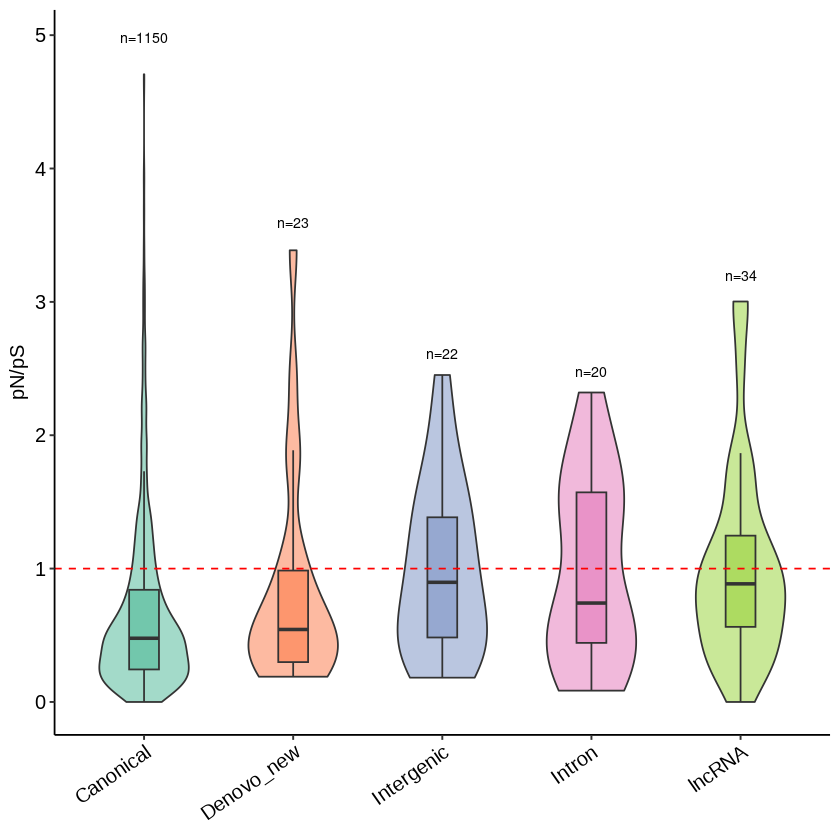

In [459]:
violin_plot_3(df_2, x = type, y = pNpS, fill = type, y_label = "pN/pS") +
  # 虚线标示
  geom_hline(yintercept = 1, linetype = "dashed", color = "red")

In [435]:
# violin_plot_1(df_1, x = type, y = pNpS, fill = type, y_label = "pN/pS") +
#   geom_dotplot(
#     data = df_1 %>% filter(type == "Denovo_old"), # 使用 filter 筛选
#     binaxis = "y", 
#     stackdir = "center"
#   )+
#   # 虚线标示
#   geom_hline(yintercept = 1, linetype = "dashed", color = "red")

In [441]:
set.seed(42)
result <- all.id.type.sites.1 %>%
  group_by(type) %>%
  mutate(
    # 随机打乱顺序后分组
    random_order = sample(n()),
    group_id = ceiling(random_order / 5)
  ) %>%
  group_by(type, group_id) %>%
  summarise(
    n_orfs = n(),
    orf_ids = paste(original_id, collapse = ";"),
    sum_nonsyn_sites = sum(`nonsyn_sites`, na.rm = TRUE),
    sum_N_Sites = sum(`N-Sites`, na.rm = TRUE),
    sum_syn_sites = sum(`syn_sites`, na.rm = TRUE),
    sum_S_Sites = sum(`S-Sites`, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    weighted_pN = ifelse(sum_N_Sites > 0, sum_nonsyn_sites / sum_N_Sites, NA),
    weighted_pS = ifelse(sum_S_Sites > 0, sum_syn_sites / sum_S_Sites, NA),
    weighted_pnps = ifelse(!is.na(weighted_pS) & weighted_pS > 0, 
                           weighted_pN / weighted_pS, NA)
  )

result %>% head()
result %>% nrow()

type,group_id,n_orfs,orf_ids,sum_nonsyn_sites,sum_N_Sites,sum_syn_sites,sum_S_Sites,weighted_pN,weighted_pS,weighted_pnps
<chr>,<dbl>,<int>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
3' UTR,1,5,ENST00000272117.8:chr1:-|250|6063:3311:3368|dORF|ATG;ENST00000320756.7:chr12:-|156|2606:2017:2095|dORF|ATG;ENST00000409101.7:chr2:-|588|6599:6226:6268|dORF|ATG;ENST00000554429.5:chr14:+|81|2977:864:1497|dORF|ATG;ENST00000699754.1:chr7:-|377|4880:4556:4625|dORF|ATG,0,680.7643,0,183.2357,0.000000000,0.000000000,NA
3' UTR,2,5,ENST00000340345.6:chr21:-|78|1642:1041:1149|dORF|ATG;ENST00000367183.7:chr1:+|60|9098:813:897|dORF|ATG;ENST00000566221.5:chr16:+|47|734:504:579|dORF|ATG;ENST00000640689.1:chr4:+|45|2080:500:545|dORF|ATG;ENST00000696521.1:chr10:-|16|1321:197:1322|dORF|ATG,6,1045.7875,1,376.2125,0.005737303,0.002658072,2.1584452
3' UTR,3,5,ENST00000371821.6:chr1:+|271|3858:3719:3752|dORF|ATG;ENST00000407242.6:chr11:-|378|4311:4049:4145|dORF|ATG;ENST00000416605.6:chr6:-|355|4729:3845:3941|dORF|ATG;ENST00000495785.1:chr1:-|34|1390:427:487|dORF|ATG;ENST00000680691.1:chr1:+|96|2359:1224:1527|dORF|ATG,2,454.2507,3,118.7488,0.004402855,0.025263413,0.1742779
3' UTR,4,5,ENST00000246069.12:chr20:+|181|3405:2081:2144|dORF|ATG;ENST00000367718.5:chr1:-|229|3429:2666:2828|dORF|ATG;ENST00000396170.5:chr11:-|329|3871:3713:3842|dORF|ATG;ENST00000463407.6:chr13:+|222|6467:2925:2970|dORF|ATG;ENST00000611898.4:chr1:-|204|2474:2107:2212|dORF|ATG,0,371.4685,0,117.5318,0.000000000,0.000000000,NA
3' UTR,5,5,ENST00000261584.9:chr16:-|285|4008:3860:3905|dORF|ATG;ENST00000356141.9:chr14:+|274|6304:3951:4152|dORF|ATG;ENST00000562220.2:chr5:+|436|12358:4547:4595|dORF|ATG;ENST00000677413.1:chr14:+|167|3486:2402:2450|dORF|ATG;ENST00000684119.1:chr19:+|402|6732:4827:4878|dORF|ATG,0,273.9803,0,104.0194,0.000000000,0.000000000,NA
3' UTR,6,5,ENST00000324559.9:chr11:+|283|6742:3392:3593|dORF|ATG;ENST00000360868.7:chr9:-|232|4341:3155:3275|dORF|ATG;ENST00000449636.6:chr11:-|130|2381:1750:1906|dORF|ATG;ENST00000609799.6:chr22:-|440|6058:5083:5131|dORF|ATG;ENST00000684187.2:chr21:+|846|13097:9420:9480|dORF|ATG,1,431.8833,0,138.1159,0.002315440,0.000000000,NA


[1] 5299

In [442]:
result %>% filter(type %in% c("Canonical","Denovo_new","Intergenic","Intron","lncRNA")) -> result
result %>% na.omit() %>% filter(weighted_pnps>0) ->result_1
table(result_1$type)


 Canonical Denovo_new Intergenic     Intron     lncRNA 
       647        138        331        341        396 

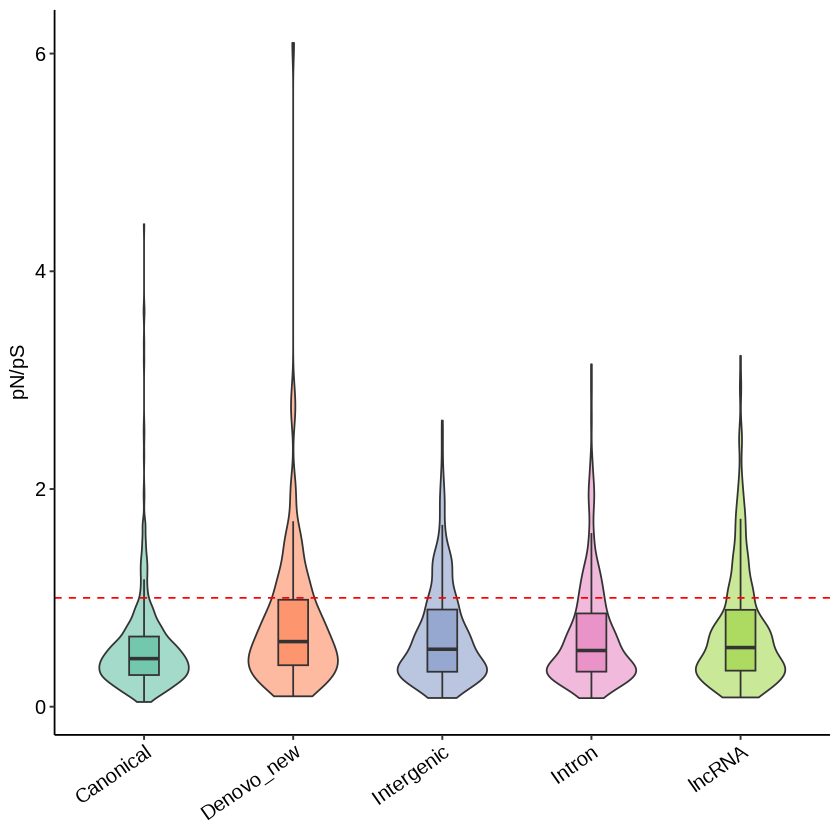

In [444]:
violin_plot_2(result_1, x = type, y = weighted_pnps, fill = type, y_label = "pN/pS") +
  # 虚线标示
  geom_hline(yintercept = 1, linetype = "dashed", color = "red")

In [462]:
compare_pnps <- function(pnps_res_path,all.id.type.sites,sum_cutoff=5){
    types <- c("Canonical","Denovo_new","Intergenic","Intron","lncRNA")
    # 导入包括新旧de novo基因以及对照的同义突变位点和非同义突变位点数量
    fread_c(pnps_res_path) -> orf_syn_nonsyn_1
    # 合并
    merge(all.id.type.sites,distinct(orf_syn_nonsyn_1,ORF_ID,syn_sites,nonsyn_sites),by.x="original_id",by.y="ORF_ID") -> all.id.type.sites.1
    all.id.type.sites.1 %>% filter(syn_sites+nonsyn_sites>=sum_cutoff) %>% filter(syn_sites>0) %>% 
    mutate(pN=nonsyn_sites/`N-Sites`, pS=syn_sites/`S-Sites`) %>%
    mutate(pNpS=pN/pS) -> df_1
    df_1 %>% filter(type %in% types) -> df_2
    violin_plot_3(df_2, x = type, y = pNpS, fill = type, y_label = "pN/pS") +
  # 虚线标示
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") ->p1

    set.seed(42)
    result <- all.id.type.sites.1 %>%
      group_by(type) %>%
      mutate(
        # 随机打乱顺序后分组
        random_order = sample(n()),
        group_id = ceiling(random_order / 5)
      ) %>%
      group_by(type, group_id) %>%
      summarise(
        n_orfs = n(),
        orf_ids = paste(original_id, collapse = ";"),
        sum_nonsyn_sites = sum(`nonsyn_sites`, na.rm = TRUE),
        sum_N_Sites = sum(`N-Sites`, na.rm = TRUE),
        sum_syn_sites = sum(`syn_sites`, na.rm = TRUE),
        sum_S_Sites = sum(`S-Sites`, na.rm = TRUE),
        .groups = "drop"
      ) %>%
      mutate(
        weighted_pN = ifelse(sum_N_Sites > 0, sum_nonsyn_sites / sum_N_Sites, NA),
        weighted_pS = ifelse(sum_S_Sites > 0, sum_syn_sites / sum_S_Sites, NA),
        weighted_pnps = ifelse(!is.na(weighted_pS) & weighted_pS > 0, 
                               weighted_pN / weighted_pS, NA)
      )
    result %>% filter(type %in% types) -> result
    result %>% na.omit() %>% filter(weighted_pnps>0) ->result_1
    violin_plot_3(result_1, x = type, y = weighted_pnps, fill = type, y_label = "pN/pS") +
  # 虚线标示
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") -> p2
  return(list(p1,p2))
}

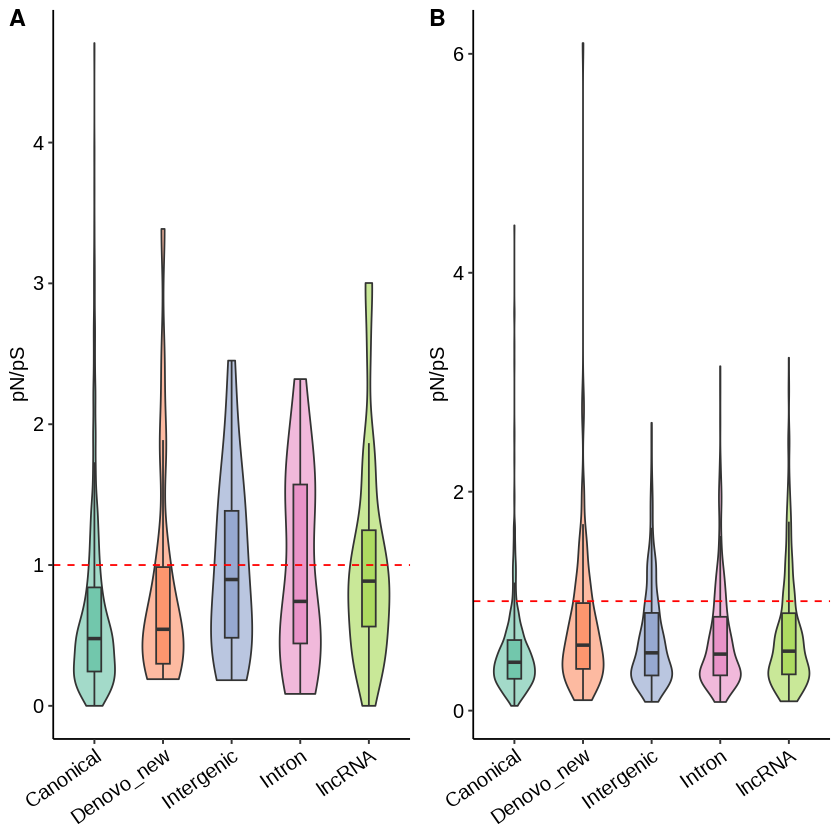

In [451]:
compare_pnps("../../processed/pnps/20251211_fine_tune/filtered_1/orf_syn_nonsyn.strict.tsv",all.id.type.sites,sum_cutoff=5) -> p_list
plot_grid(p_list[[1]],p_list[[2]],ncol = 2, labels = "AUTO")

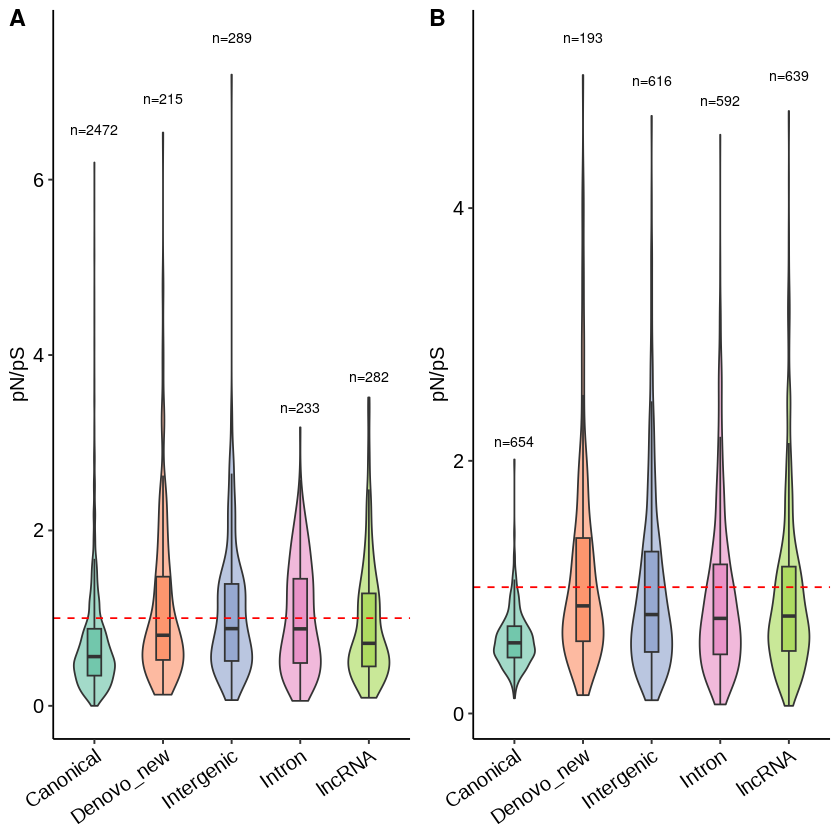

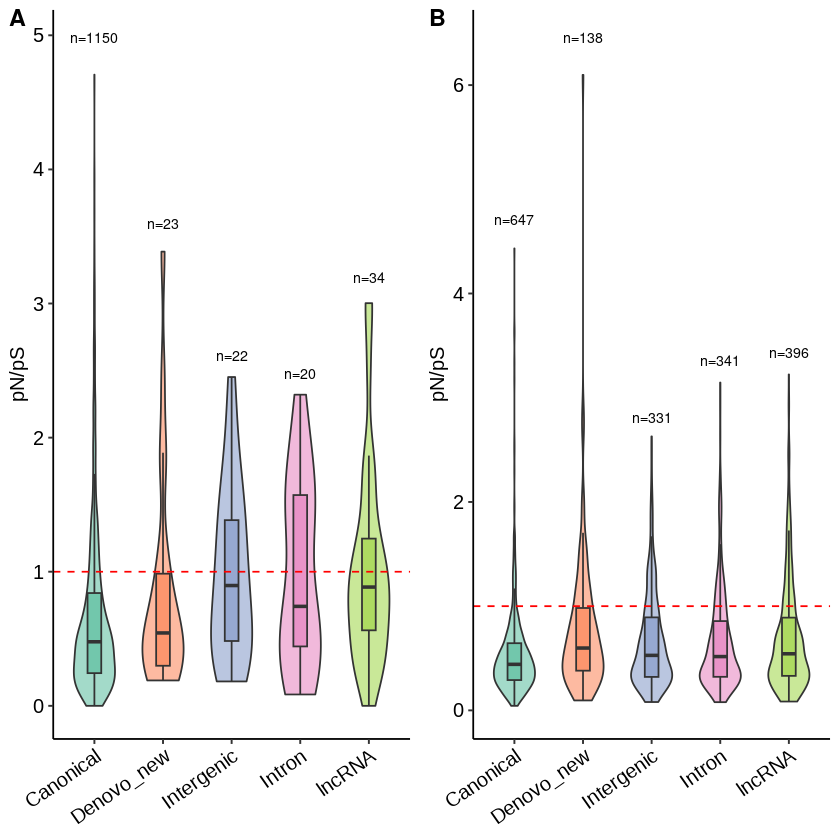

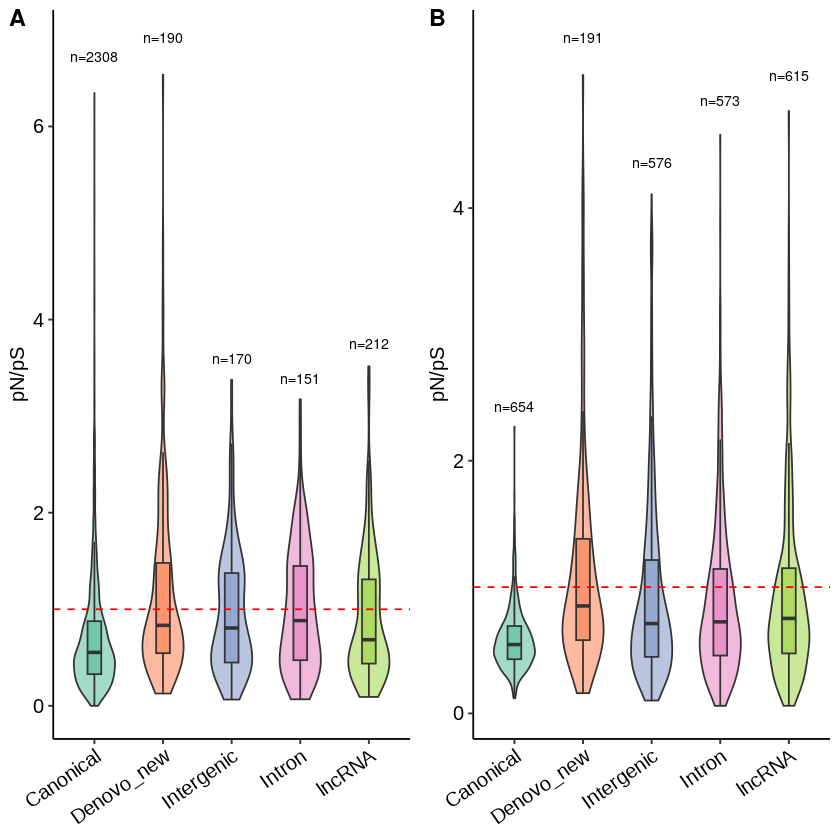

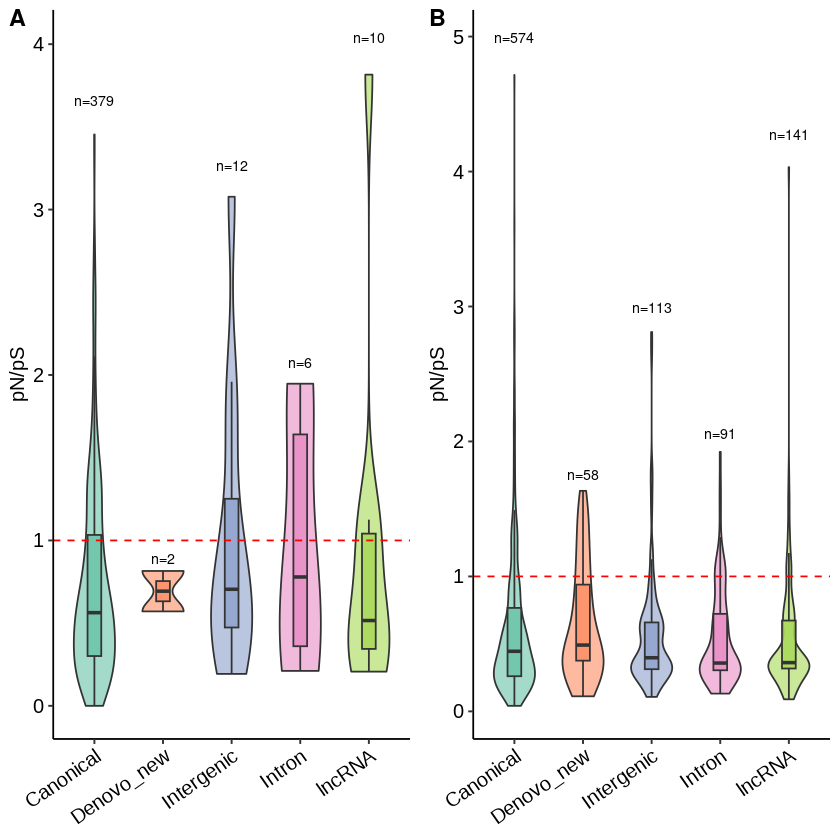

In [463]:
for(file in c("../../processed/pnps/20251211_fine_tune/filtered_0/orf_syn_nonsyn.strict.tsv",
    "../../processed/pnps/20251211_fine_tune/filtered_1/orf_syn_nonsyn.strict.tsv",
              "../../processed/pnps/20251211_fine_tune/filtered_2/orf_syn_nonsyn.strict.tsv",
              "../../processed/pnps/20251211_fine_tune/filtered_3/orf_syn_nonsyn.strict.tsv")){
    compare_pnps(file, all.id.type.sites, sum_cutoff=5) -> p_list
    plot_grid(p_list[[1]], p_list[[2]], ncol = 2, labels = "AUTO") %>% print()
}

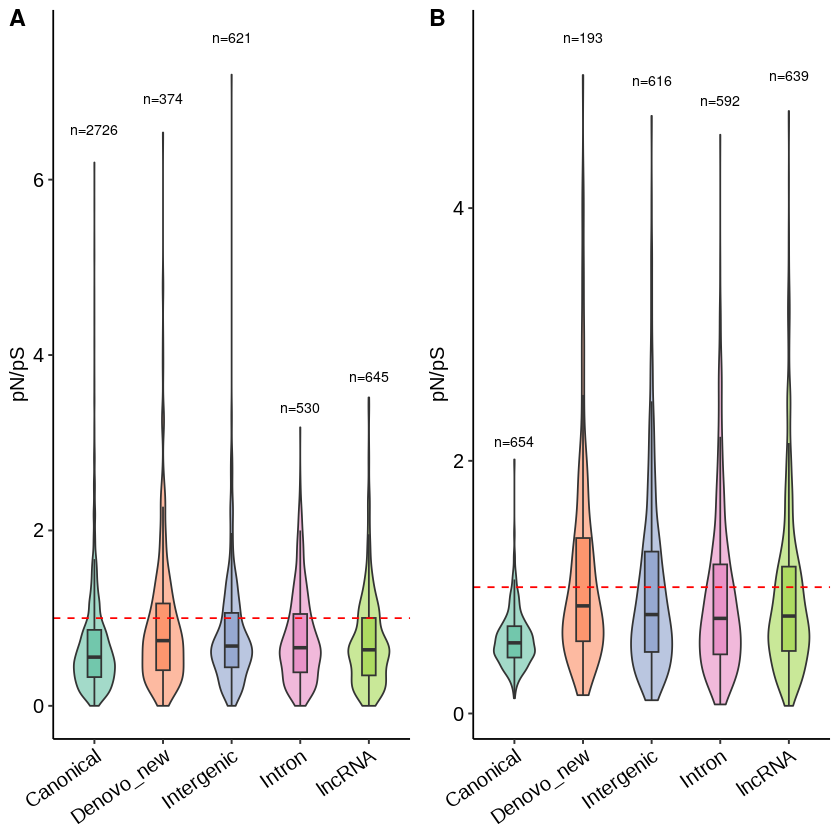

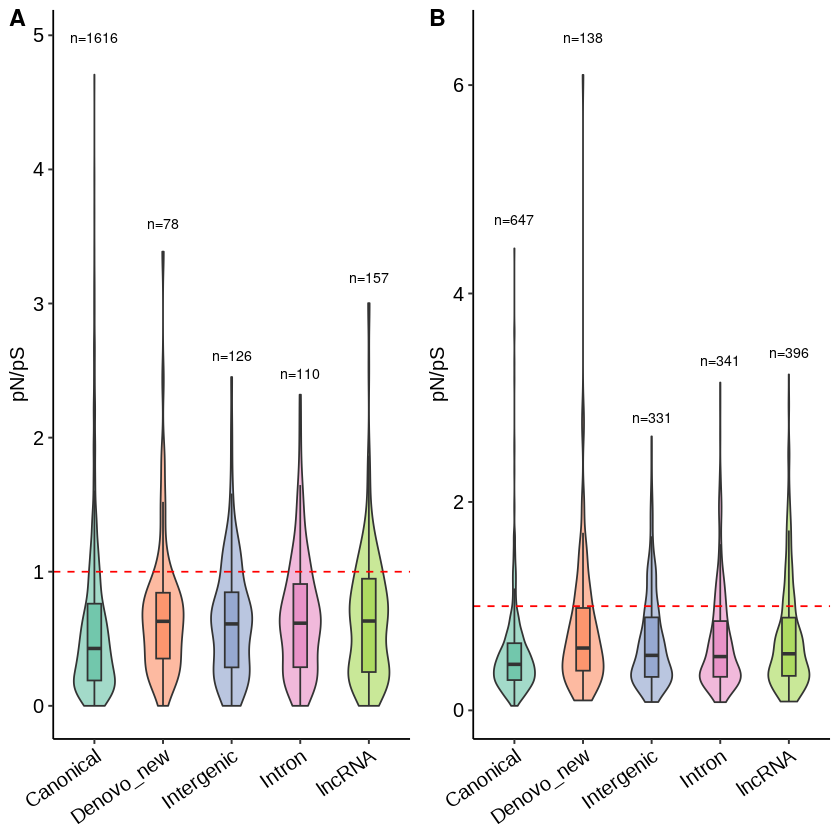

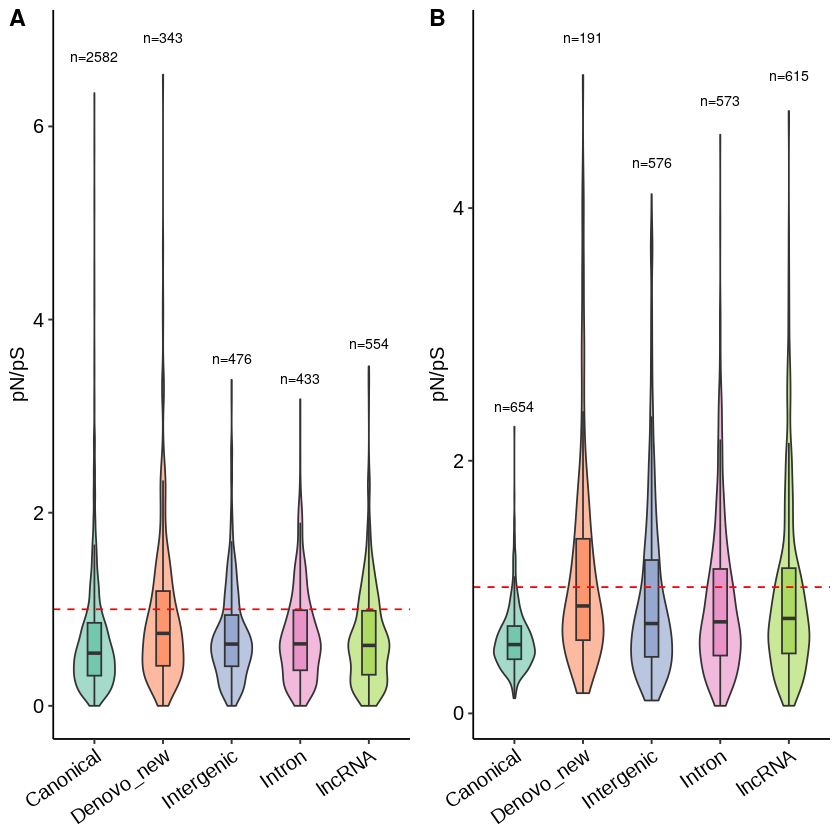

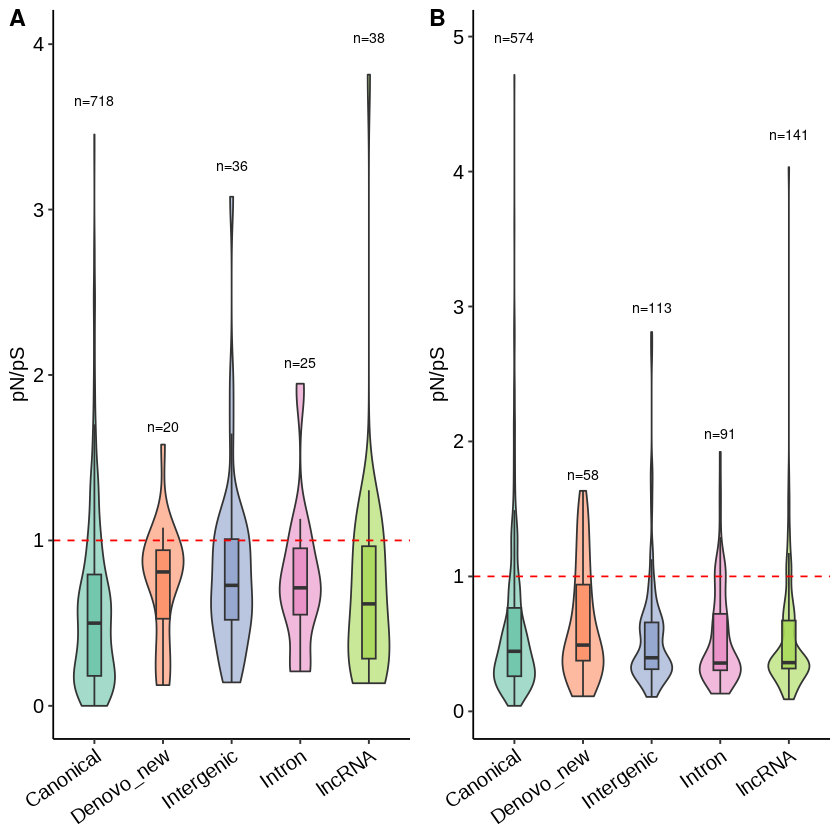

In [464]:
for(file in c("../../processed/pnps/20251211_fine_tune/filtered_0/orf_syn_nonsyn.strict.tsv",
    "../../processed/pnps/20251211_fine_tune/filtered_1/orf_syn_nonsyn.strict.tsv",
              "../../processed/pnps/20251211_fine_tune/filtered_2/orf_syn_nonsyn.strict.tsv",
              "../../processed/pnps/20251211_fine_tune/filtered_3/orf_syn_nonsyn.strict.tsv")){
    compare_pnps(file, all.id.type.sites, sum_cutoff=3) -> p_list
    plot_grid(p_list[[1]], p_list[[2]], ncol = 2, labels = "AUTO") %>% print()
}

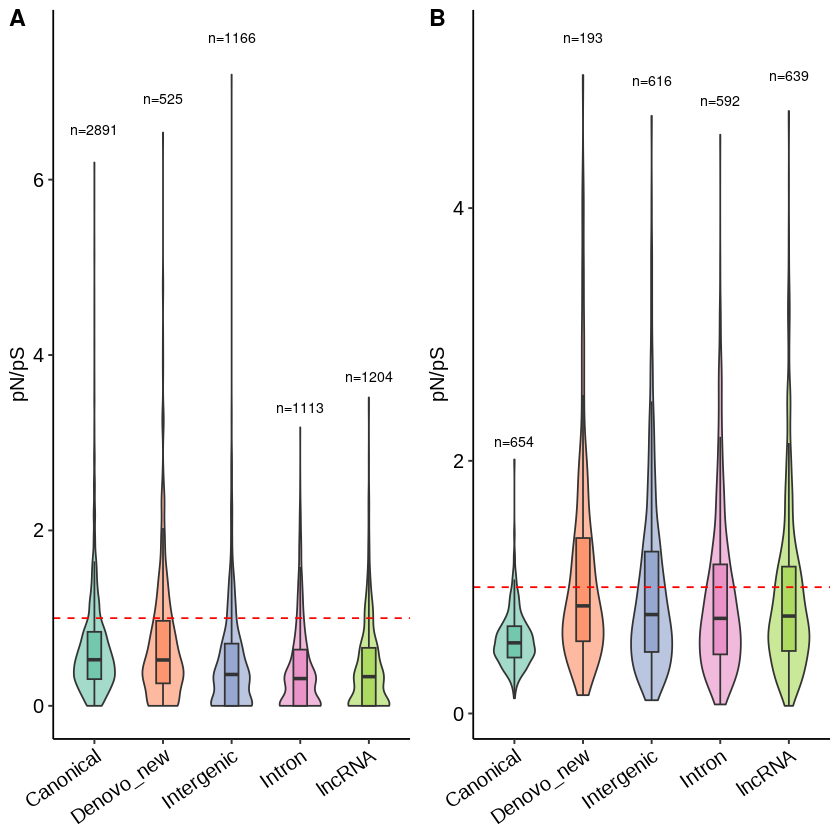

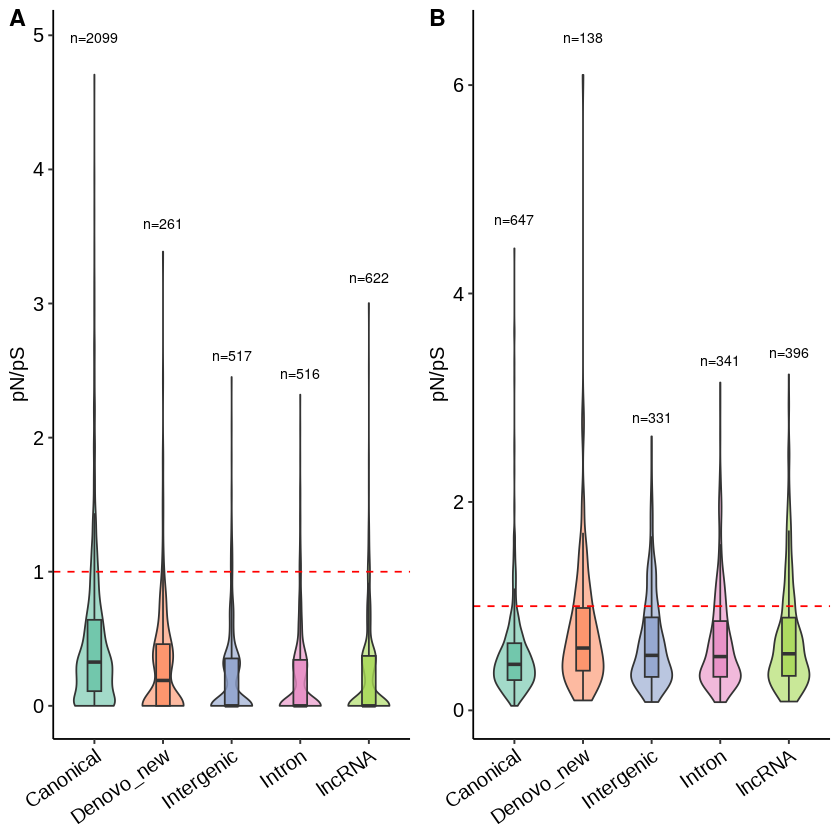

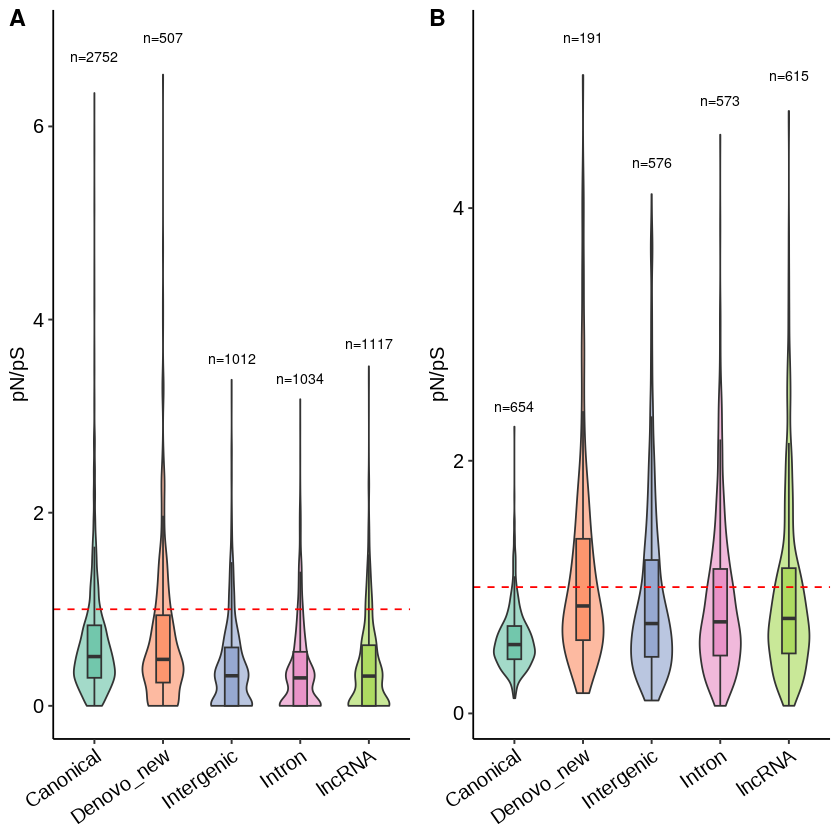

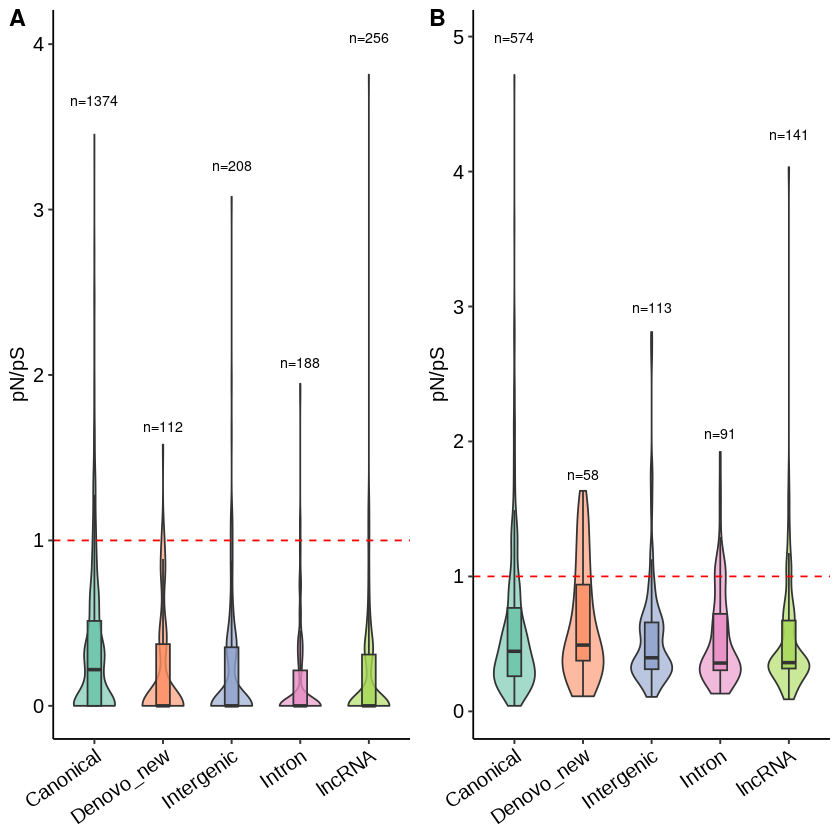

In [465]:
for(file in c("../../processed/pnps/20251211_fine_tune/filtered_0/orf_syn_nonsyn.strict.tsv",
    "../../processed/pnps/20251211_fine_tune/filtered_1/orf_syn_nonsyn.strict.tsv",
              "../../processed/pnps/20251211_fine_tune/filtered_2/orf_syn_nonsyn.strict.tsv",
              "../../processed/pnps/20251211_fine_tune/filtered_3/orf_syn_nonsyn.strict.tsv")){
    compare_pnps(file, all.id.type.sites, sum_cutoff=1) -> p_list
    plot_grid(p_list[[1]], p_list[[2]], ncol = 2, labels = "AUTO") %>% print()
}